# Looking into neurons with high w_out

Do these neurons have something in common / is it always the same neurons

In [1]:
import numpy as np 
import sys
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import scipy
import os
import importlib
import pandas as pd

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld 
import lfp_utils as lu
import rate_neuron_utils as rn
from bootstrap_method import *

2026-04-30 10:34:34.897537: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-30 10:34:34.907130: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-30 10:34:34.916409: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-30 10:34:34.919220: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-30 10:34:34.927082: I tensorflow/core/platform/cpu_feature_guar

In [2]:
delay = 200
condn_phrase = 'delay'
condn_num = delay

# condn_key = f'{condn_phrase}{condn_num}'

In [3]:
all_models_dir = '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5'

model_paths = ld.find_files(all_models_dir, '*N_1000*.mat')
model_names = [os.path.basename(m)[:-4] for m in model_paths]
print(len(model_names))
print(model_names)

8
['Task_sternberg_N_1000_Jitter_5_3_2026_04_14_044205', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_17_174533', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_17_155940', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_14_061957', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_14_014713', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_14_052959', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_17_140925', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_14_025058']


### visualize single model

In [4]:
# choose a model to visualize for now
model_name = model_names[0]
model_dir = os.path.join(all_models_dir, model_name)

In [5]:
# neural data
_, rates_data_match = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= "balance_match",
                                            all_models_dir = all_models_dir, load_LFP=False)
_, rates_data_stim = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= "balance_stim",
                                            all_models_dir = all_models_dir, load_LFP=False)
rates_data = np.concatenate((rates_data_match, rates_data_stim), axis=0)
print(rates_data.shape)

# behavioral data
trial_labels_match, trial_perfs_match, trial_outputs_match = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                    other_labels="balance_match",
                                                    all_models_dir=all_models_dir)
trial_labels_stim, trial_perfs_stim, trial_outputs_stim = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                    other_labels="balance_stim",
                                                    all_models_dir=all_models_dir)
trial_labels = np.concatenate((trial_labels_match, trial_labels_stim), axis=0)

settings = ld.load_settings_rate_data(model_name, condn_phrase, condn_num,
                                      other_labels="balance_stim",
                                      all_models_dir=all_models_dir)

load_tuning = rn.calc_load_tuning(model_name, condn_phrase, condn_num, 
                                other_labels = "balance_match",
                                all_models_dir=all_models_dir)

stim1_tuning = np.load(os.path.join(model_dir, 'stim1_tuning_nonparametric.npz'))['stim1_tuning']

(536, 1000, 450)


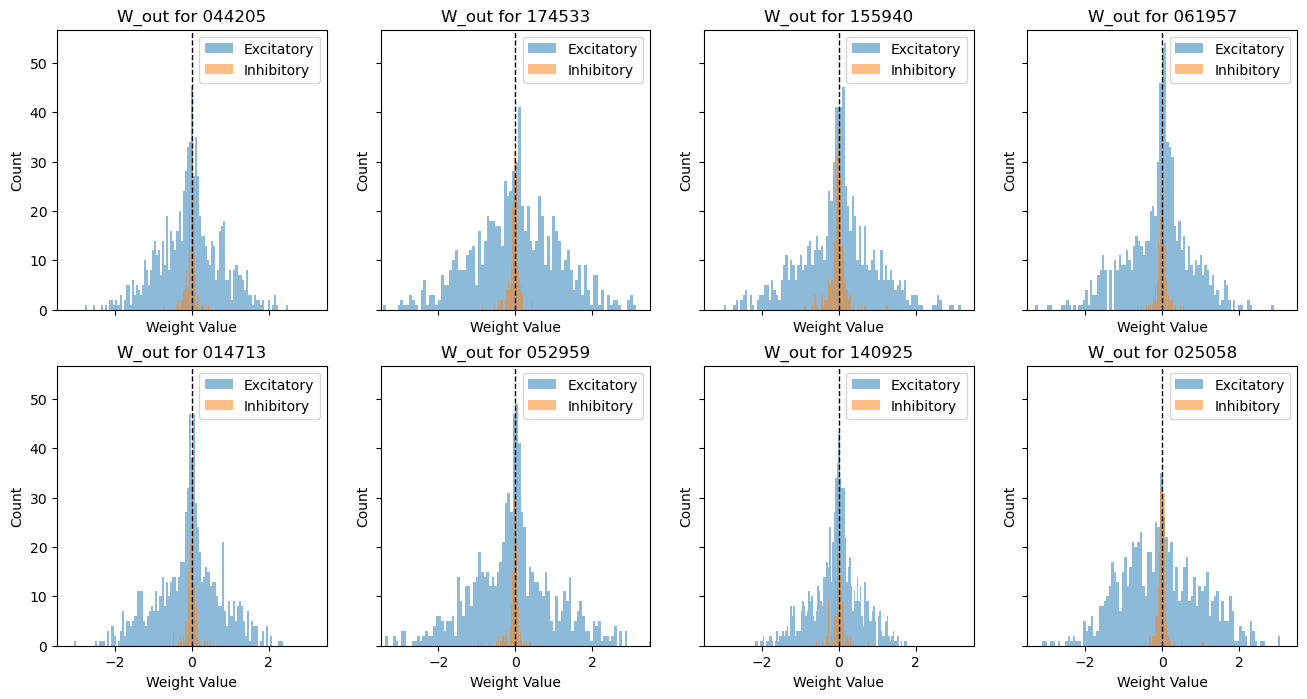

In [13]:
# check out w_out for this model
importlib.reload(ld)

fig, axs = plt.subplots(2,4, figsize=(16,8), sharex=True, sharey=True)
axs = axs.flatten()
for i, model_name in enumerate(model_names):

    w_out = ld.get_w_out(model_name, all_models_dir=all_models_dir)

    exc_ind, inh_ind = ld.get_celltype_label(model_name, all_models_dir=all_models_dir)
    axs[i].hist(w_out[exc_ind], bins=100, alpha=0.5, label='Excitatory')
    axs[i].hist(w_out[inh_ind], bins=50, alpha=0.5, label='Inhibitory')
    axs[i].set_title(f'W_out for {model_name[-6:]}')
    axs[i].set_xlabel('Weight Value')
    axs[i].set_ylabel('Count')
    axs[i].set_xlim(-3.5, 3.5)
    
    # draw vertical line at 0
    axs[i].axvline(0, color='black', linestyle='--', linewidth=1)
    # # draw vertical lines at mean of excitatory and inhibitory weights
    # axs[i].axvline(np.mean(w_out[exc_ind]), color='blue', linestyle='--', linewidth=1, label='Mean Excitatory')
    # axs[i].axvline(np.mean(w_out[inh_ind]), color='orange', linestyle='--', linewidth=1, label='Mean Inhibitory')
    axs[i].legend() 

plt.show()

In [14]:
rates_data[:,:,400].shape

(536, 1000)

## all trials (combine balance match and balance stim)

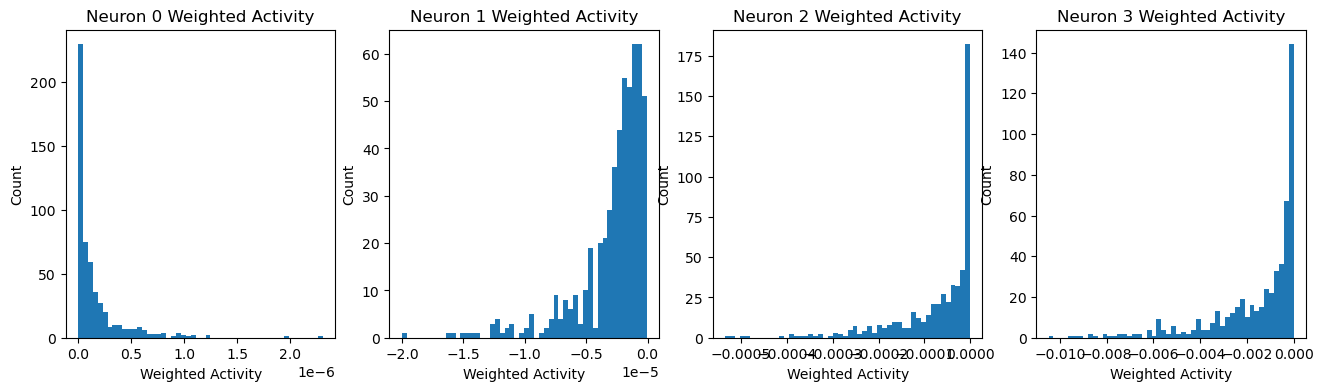

In [17]:
model_name = model_names[0]
model_dir = os.path.join(all_models_dir, model_name)

importlib.reload(ld)
w_out = ld.get_w_out(model_name, all_models_dir=all_models_dir)

# check if w_out * r is consistent no matter the trial type
weighted_r = w_out * rates_data[:,:,400]

# check distribution of a couple of neurons across all trials
fig, axs = plt.subplots(1, 4, figsize=(16,4))
for i in range(4):
    axs[i].hist(weighted_r[:,i], bins=50)
    axs[i].set_title(f'Neuron {i} Weighted Activity')
    axs[i].set_xlabel('Weighted Activity')
    axs[i].set_ylabel('Count')
plt.show()

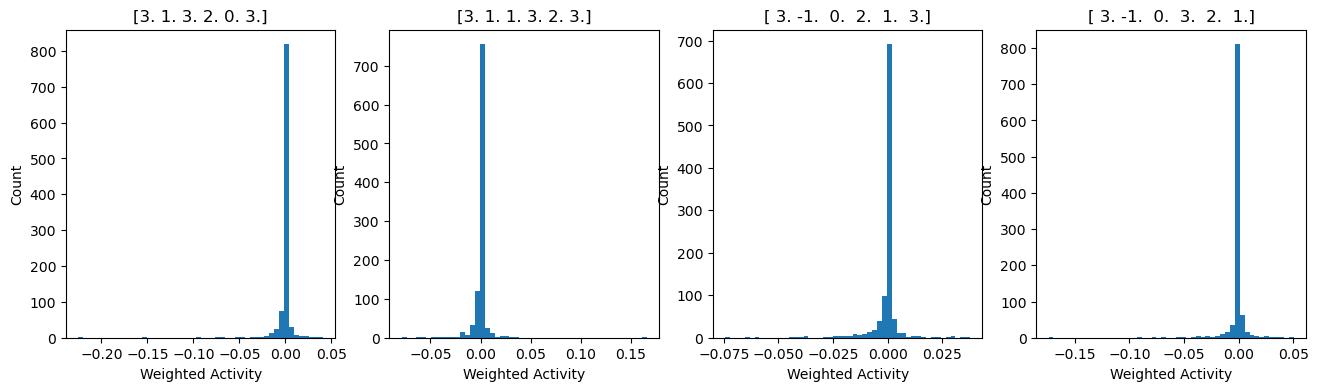

In [18]:
# check weighted r's for a couple of trials
trial_idxs = np.random.choice(rates_data.shape[0], size=4, replace=False)
fig, axs = plt.subplots(1, 4, figsize=(16,4))
for i, trial_idx in enumerate(trial_idxs):
    axs[i].hist(weighted_r[trial_idx,:], bins=50)
    axs[i].set_title(trial_labels[trial_idx])
    axs[i].set_xlabel('Weighted Activity')
    axs[i].set_ylabel('Count')
plt.show()

In [20]:
top_neuron_idxs

array([305, 242, 258, 427, 185, 709, 825, 133, 278, 330])

In [ ]:
# get the top 1% of neurons with absolute weighted activity in each trial

top_idxs = []
top_values = []
for trial_idx in range(weighted_r.shape[0]):
    top_neuron_idxs = np.argsort(np.abs(weighted_r[trial_idx,:]))[-int(0.01*weighted_r.shape[1]):]
    top_idxs.append(top_neuron_idxs)
    top_values.append(weighted_r[trial_idx, top_neuron_idxs])


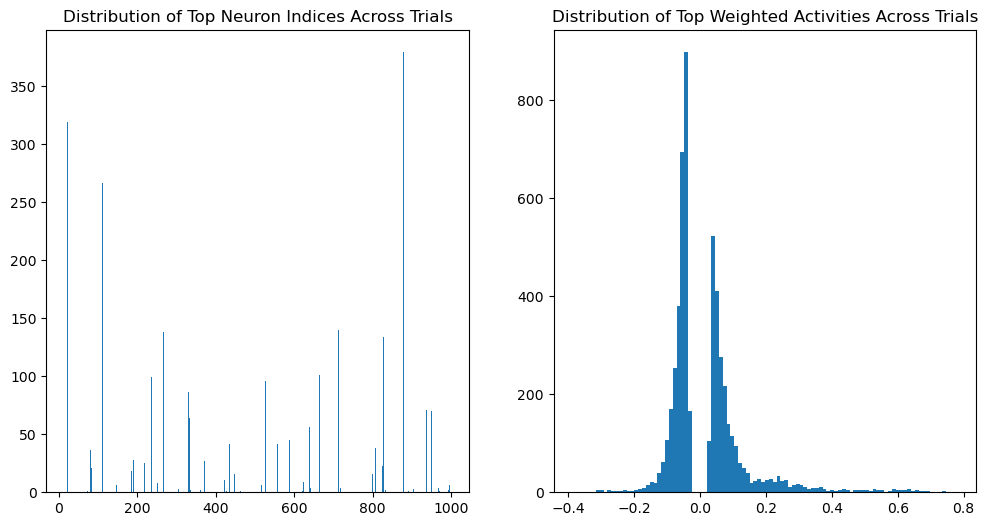

In [24]:
fig, axs = plt.subplots(1,2, figsize=(12,6))
axs[0].hist(np.array(top_idxs).flatten(), bins=1000)
axs[0].set_title('Distribution of Top Neuron Indices Across Trials')
axs[1].hist(np.array(top_values).flatten(), bins=100)
axs[1].set_title('Distribution of Top Weighted Activities Across Trials')
plt.show()


In [25]:
top_idxs_flat = np.array(top_idxs).flatten()
unique, counts = np.unique(top_idxs_flat, return_counts=True)
top_neuron_counts = dict(zip(unique, counts))
print("Top Neuron Counts:", top_neuron_counts)

Top Neuron Counts: {17: 1, 18: 6, 22: 319, 28: 14, 33: 1, 49: 25, 72: 2, 73: 1, 80: 36, 81: 1, 83: 21, 84: 158, 110: 1, 112: 266, 120: 5, 123: 225, 133: 26, 147: 6, 149: 17, 170: 1, 176: 18, 185: 18, 190: 28, 194: 127, 200: 3, 204: 14, 205: 113, 212: 4, 218: 25, 220: 2, 224: 2, 236: 99, 238: 1, 242: 174, 246: 6, 252: 8, 258: 76, 266: 138, 278: 48, 293: 54, 301: 9, 305: 3, 318: 10, 326: 5, 330: 86, 333: 64, 336: 2, 339: 4, 344: 9, 361: 2, 371: 27, 382: 2, 399: 257, 418: 95, 421: 25, 422: 11, 427: 1, 435: 42, 448: 16, 452: 1, 457: 3, 462: 5, 463: 1, 475: 19, 479: 31, 507: 1, 516: 6, 527: 96, 547: 2, 557: 42, 588: 45, 602: 7, 621: 1, 624: 9, 639: 56, 642: 4, 649: 74, 657: 54, 663: 7, 664: 101, 671: 12, 697: 96, 709: 22, 711: 78, 712: 32, 713: 140, 717: 1, 718: 4, 735: 51, 765: 168, 767: 4, 773: 2, 793: 24, 800: 16, 807: 38, 825: 23, 828: 134, 832: 13, 833: 2, 834: 3, 845: 11, 860: 51, 872: 12, 877: 208, 879: 379, 892: 1, 903: 90, 904: 3, 905: 15, 938: 71, 939: 21, 945: 40, 950: 70, 951: 3

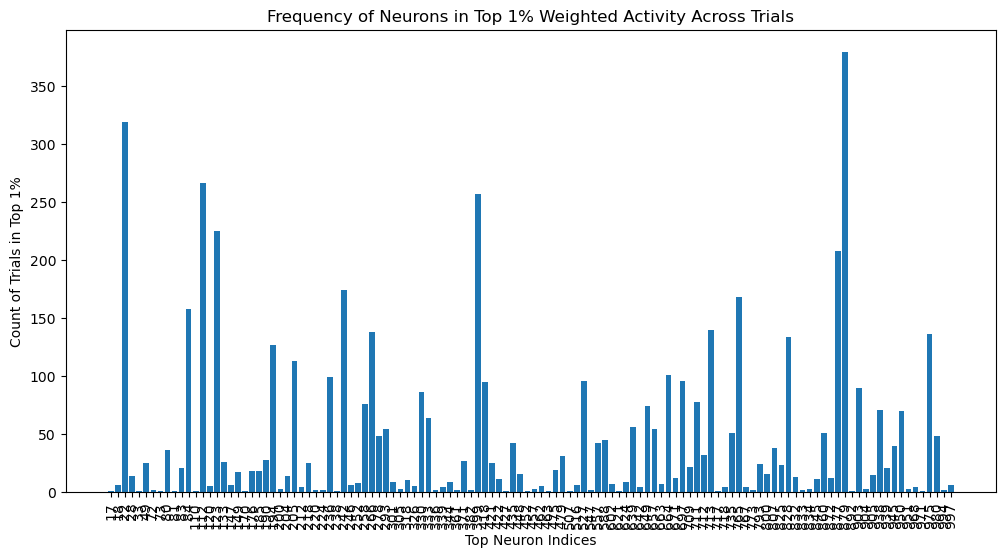

In [28]:
# bar plot of the top neurons
plt.figure(figsize=(12,6))
plt.bar(range(len(top_neuron_counts)), list(top_neuron_counts.values()))
plt.xticks(ticks=range(len(top_neuron_counts)), labels=top_neuron_counts.keys(), rotation=90)
plt.xlabel('Top Neuron Indices')
plt.ylabel('Count of Trials in Top 1%')
plt.title('Frequency of Neurons in Top 1% Weighted Activity Across Trials')
plt.show()

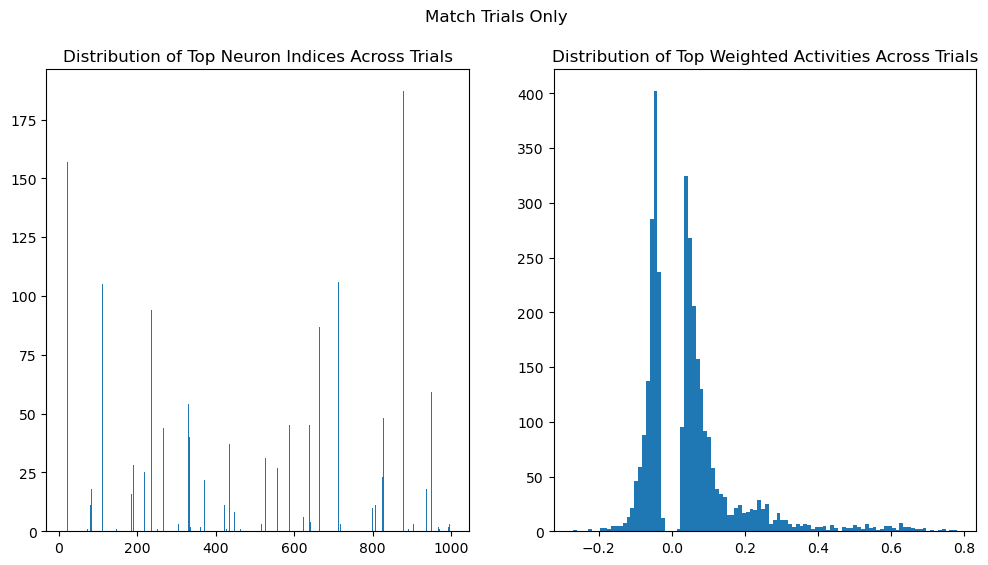

In [33]:
# how about just match trials?

match_trial_idxs = np.where(trial_labels[:,1] == 1)[0]
top_idxs_match = [top_idxs[i] for i in match_trial_idxs]
top_values_match = [top_values[i] for i in match_trial_idxs]

fig, axs = plt.subplots(1,2, figsize=(12,6))
axs[0].hist(np.array(top_idxs_match).flatten(), bins=1000)
axs[0].set_title('Distribution of Top Neuron Indices Across Trials')
axs[1].hist(np.array(top_values_match).flatten(), bins=100)
axs[1].set_title('Distribution of Top Weighted Activities Across Trials')
plt.suptitle('Match Trials Only')
plt.show()

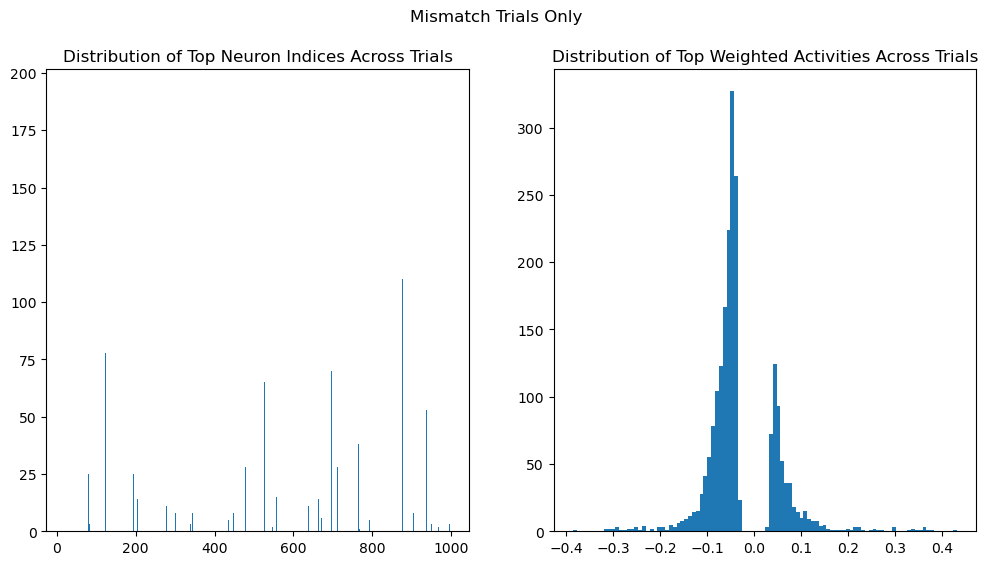

In [34]:
# now mismatch

mismatch_trial_idxs = np.where(trial_labels[:,1] == -1)[0]
top_idxs_mismatch = [top_idxs[i] for i in mismatch_trial_idxs]
top_values_mismatch = [top_values[i] for i in mismatch_trial_idxs]

fig, axs = plt.subplots(1,2, figsize=(12,6))
axs[0].hist(np.array(top_idxs_mismatch).flatten(), bins=1000)
axs[0].set_title('Distribution of Top Neuron Indices Across Trials')
axs[1].hist(np.array(top_values_mismatch).flatten(), bins=100)
axs[1].set_title('Distribution of Top Weighted Activities Across Trials')
plt.suptitle('Mismatch Trials Only')
plt.show()

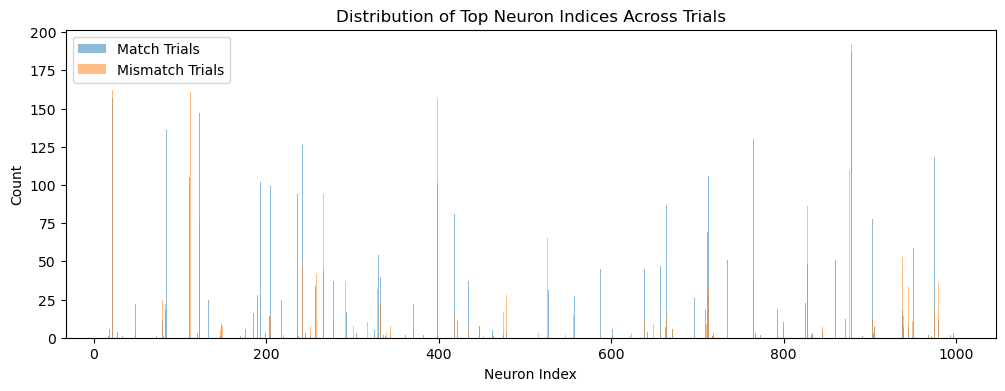

In [ ]:
# how different are the top neurons for match vs mismatch trials?

plt.figure(figsize=(12,4))
plt.hist(np.array(top_idxs_match).flatten(), bins=1000, alpha=0.5, label='Match Trials')
plt.hist(np.array(top_idxs_mismatch).flatten(), bins=1000, alpha=0.5, label='Mismatch Trials')
plt.title('Distribution of Top Neuron Indices Across Trials')
plt.xlabel('Neuron Index')
plt.ylabel('Count')
plt.legend()
plt.show()

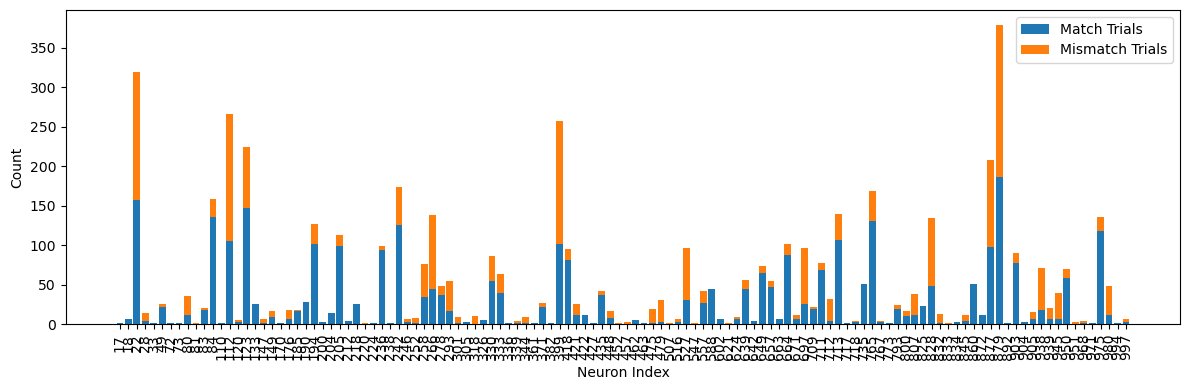

In [38]:
# Flatten + count
top_idxs_match_flat = np.array(top_idxs_match).flatten()
match_unique, match_counts = np.unique(top_idxs_match_flat, return_counts=True)
top_neuron_counts_match = dict(zip(match_unique, match_counts))

top_idxs_mismatch_flat = np.array(top_idxs_mismatch).flatten()
mismatch_unique, mismatch_counts = np.unique(top_idxs_mismatch_flat, return_counts=True)
top_neuron_counts_mismatch = dict(zip(mismatch_unique, mismatch_counts))

# Combine all neuron indices
all_neurons = sorted(set(top_neuron_counts_match) | set(top_neuron_counts_mismatch))

# Condensed x positions
x_pos = np.arange(len(all_neurons))

# Values aligned to condensed axis
match_vals = [top_neuron_counts_match.get(n, 0) for n in all_neurons]
mismatch_vals = [top_neuron_counts_mismatch.get(n, 0) for n in all_neurons]

# Plot
plt.figure(figsize=(12, 4))

plt.bar(x_pos, match_vals, label='Match Trials')
plt.bar(x_pos, mismatch_vals, bottom=match_vals, label='Mismatch Trials')

# Use original neuron indices as labels
plt.xticks(x_pos, all_neurons, rotation=90)

plt.xlabel('Neuron Index')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

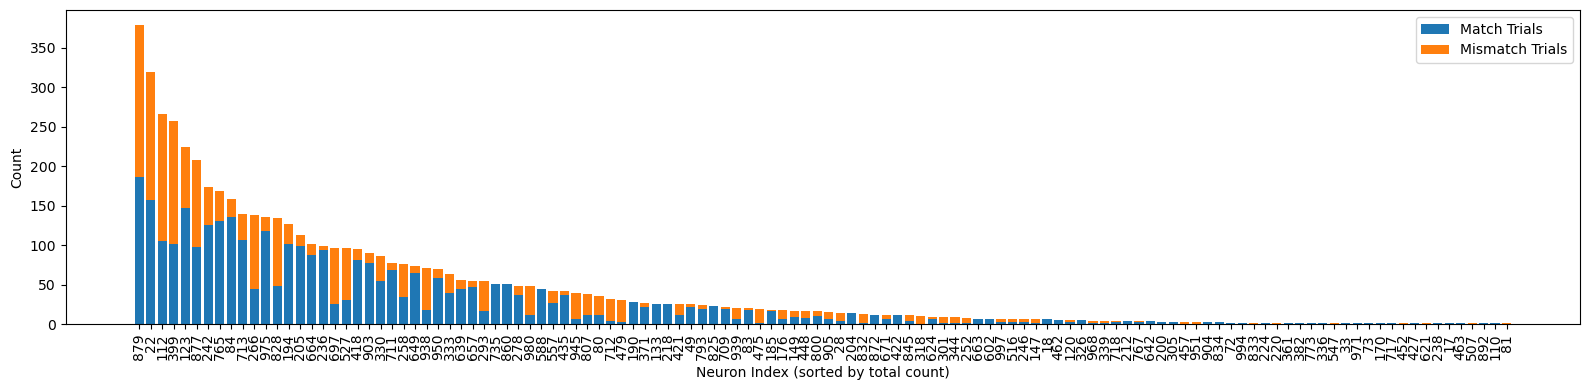

In [40]:
# Flatten + count
top_idxs_match_flat = np.array(top_idxs_match).flatten()
match_unique, match_counts = np.unique(top_idxs_match_flat, return_counts=True)
top_neuron_counts_match = dict(zip(match_unique, match_counts))

top_idxs_mismatch_flat = np.array(top_idxs_mismatch).flatten()
mismatch_unique, mismatch_counts = np.unique(top_idxs_mismatch_flat, return_counts=True)
top_neuron_counts_mismatch = dict(zip(mismatch_unique, mismatch_counts))

# Combine neuron indices
all_neurons = sorted(set(top_neuron_counts_match) | set(top_neuron_counts_mismatch))

# Get aligned values
match_vals = np.array([top_neuron_counts_match.get(n, 0) for n in all_neurons])
mismatch_vals = np.array([top_neuron_counts_mismatch.get(n, 0) for n in all_neurons])

# --- SORT by total count (descending) ---
totals = match_vals + mismatch_vals
order = np.argsort(totals)[::-1]

all_neurons = np.array(all_neurons)[order]
match_vals = match_vals[order]
mismatch_vals = mismatch_vals[order]

# Condensed x positions
x_pos = np.arange(len(all_neurons))

# Plot
plt.figure(figsize=(16, 4))

plt.bar(x_pos, match_vals, label='Match Trials')
plt.bar(x_pos, mismatch_vals, bottom=match_vals, label='Mismatch Trials')

plt.xticks(x_pos, all_neurons, rotation=90)

plt.xlabel('Neuron Index (sorted by total count)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

## only balance match/mismatch trials

In [42]:
model_name = model_names[0]
model_dir = os.path.join(all_models_dir, model_name)

importlib.reload(ld)
w_out = ld.get_w_out(model_name, all_models_dir=all_models_dir)

# check if w_out * r is consistent no matter the trial type
weighted_r = w_out * rates_data_match[:,:,400]


### top 1% of neurons

In [43]:
# get the top 1% of neurons with absolute weighted activity in each trial

top_idxs = []
top_values = []
for trial_idx in range(weighted_r.shape[0]):
    top_neuron_idxs = np.argsort(np.abs(weighted_r[trial_idx,:]))[-int(0.01*weighted_r.shape[1]):]
    top_idxs.append(top_neuron_idxs)
    top_values.append(weighted_r[trial_idx, top_neuron_idxs])


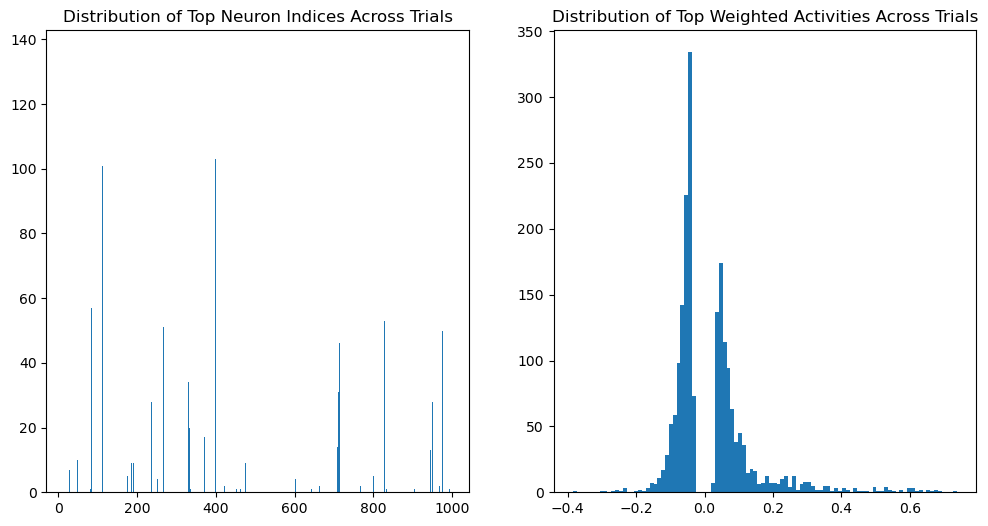

In [44]:
fig, axs = plt.subplots(1,2, figsize=(12,6))
axs[0].hist(np.array(top_idxs).flatten(), bins=1000)
axs[0].set_title('Distribution of Top Neuron Indices Across Trials')
axs[1].hist(np.array(top_values).flatten(), bins=100)
axs[1].set_title('Distribution of Top Weighted Activities Across Trials')
plt.show()


In [45]:
top_idxs_flat = np.array(top_idxs).flatten()
unique, counts = np.unique(top_idxs_flat, return_counts=True)
top_neuron_counts = dict(zip(unique, counts))
print("Top Neuron Counts:", top_neuron_counts)

Top Neuron Counts: {18: 4, 22: 114, 28: 7, 49: 10, 72: 1, 80: 13, 81: 1, 83: 12, 84: 57, 110: 1, 112: 101, 120: 4, 123: 84, 133: 14, 149: 6, 176: 5, 185: 9, 190: 9, 194: 38, 200: 3, 204: 9, 205: 42, 218: 8, 220: 2, 224: 1, 236: 28, 242: 57, 246: 1, 252: 4, 258: 26, 266: 51, 278: 22, 293: 26, 301: 3, 318: 4, 326: 1, 330: 34, 333: 20, 336: 1, 339: 1, 344: 2, 371: 17, 399: 103, 418: 30, 421: 11, 422: 2, 435: 14, 448: 6, 452: 1, 457: 1, 462: 2, 463: 1, 475: 9, 479: 15, 507: 1, 516: 1, 527: 42, 547: 2, 557: 12, 588: 14, 602: 4, 624: 2, 639: 22, 642: 1, 649: 34, 657: 19, 663: 2, 664: 43, 671: 5, 697: 38, 709: 14, 711: 31, 712: 16, 713: 46, 735: 14, 765: 59, 767: 2, 773: 2, 793: 6, 800: 5, 807: 12, 825: 14, 828: 53, 832: 6, 833: 1, 845: 4, 860: 16, 872: 7, 877: 80, 879: 136, 892: 1, 903: 29, 904: 1, 905: 4, 938: 22, 939: 9, 945: 13, 950: 28, 951: 1, 968: 2, 975: 50, 980: 25, 994: 1}


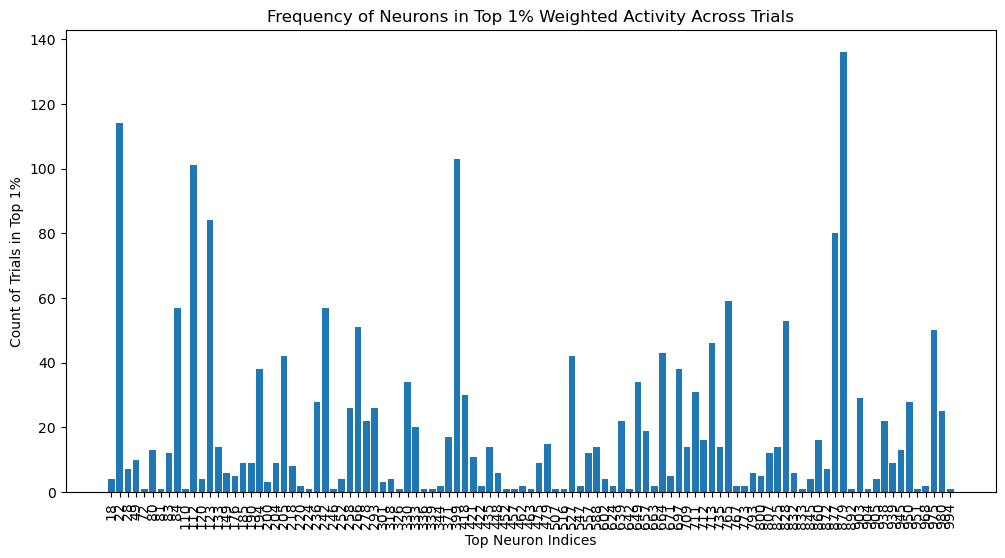

In [46]:
# bar plot of the top neurons
plt.figure(figsize=(12,6))
plt.bar(range(len(top_neuron_counts)), list(top_neuron_counts.values()))
plt.xticks(ticks=range(len(top_neuron_counts)), labels=top_neuron_counts.keys(), rotation=90)
plt.xlabel('Top Neuron Indices')
plt.ylabel('Count of Trials in Top 1%')
plt.title('Frequency of Neurons in Top 1% Weighted Activity Across Trials')
plt.show()

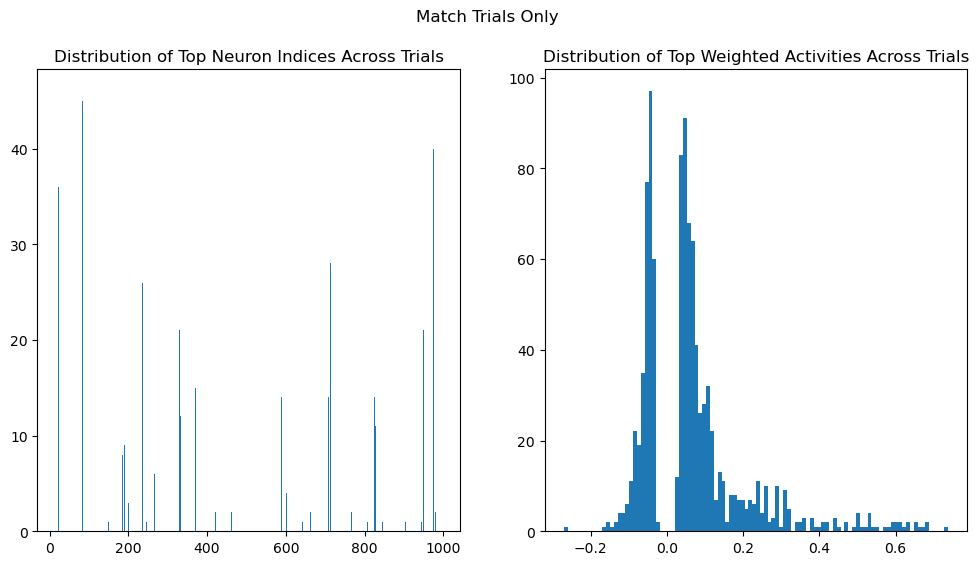

In [48]:
# how about just match trials?

match_trial_idxs = np.where(trial_labels_match[:,1] == 1)[0]
top_idxs_match = [top_idxs[i] for i in match_trial_idxs]
top_values_match = [top_values[i] for i in match_trial_idxs]

fig, axs = plt.subplots(1,2, figsize=(12,6))
axs[0].hist(np.array(top_idxs_match).flatten(), bins=1000)
axs[0].set_title('Distribution of Top Neuron Indices Across Trials')
axs[1].hist(np.array(top_values_match).flatten(), bins=100)
axs[1].set_title('Distribution of Top Weighted Activities Across Trials')
plt.suptitle('Match Trials Only')
plt.show()

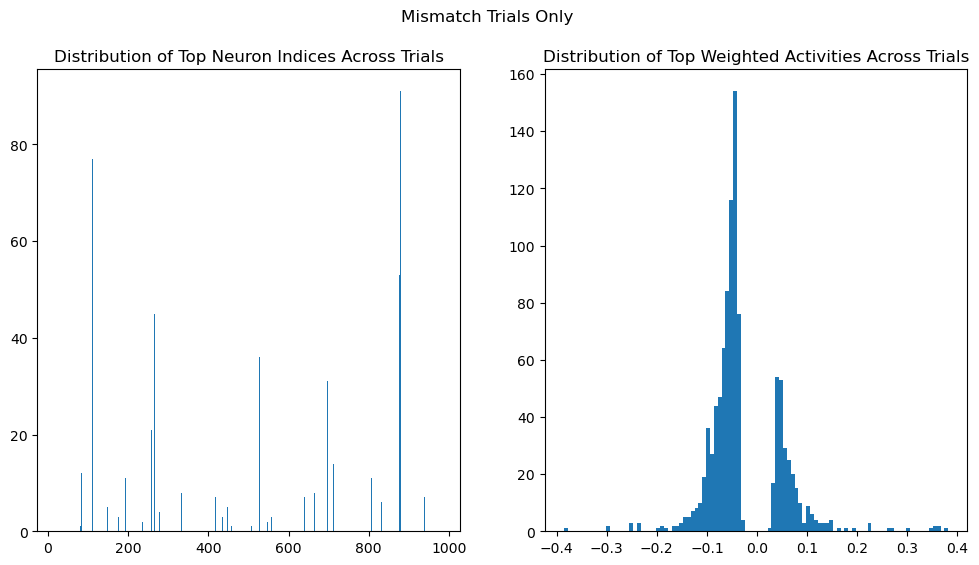

In [49]:
# now mismatch

mismatch_trial_idxs = np.where(trial_labels_match[:,1] == -1)[0]
top_idxs_mismatch = [top_idxs[i] for i in mismatch_trial_idxs]
top_values_mismatch = [top_values[i] for i in mismatch_trial_idxs]

fig, axs = plt.subplots(1,2, figsize=(12,6))
axs[0].hist(np.array(top_idxs_mismatch).flatten(), bins=1000)
axs[0].set_title('Distribution of Top Neuron Indices Across Trials')
axs[1].hist(np.array(top_values_mismatch).flatten(), bins=100)
axs[1].set_title('Distribution of Top Weighted Activities Across Trials')
plt.suptitle('Mismatch Trials Only')
plt.show()

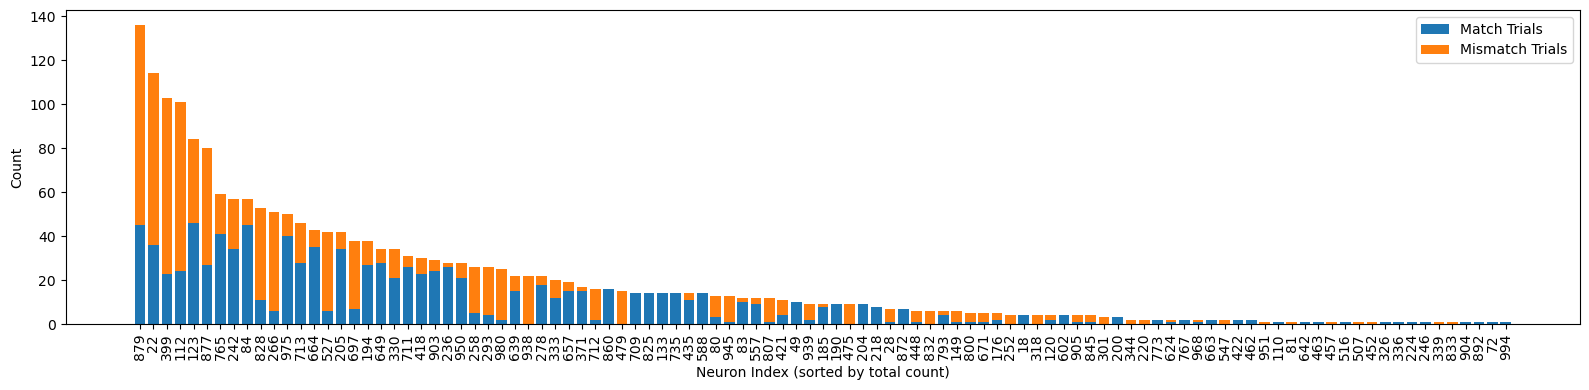

In [51]:
# how different are the top neurons for match vs mismatch trials?

# Flatten + count
top_idxs_match_flat = np.array(top_idxs_match).flatten()
match_unique, match_counts = np.unique(top_idxs_match_flat, return_counts=True)
top_neuron_counts_match = dict(zip(match_unique, match_counts))

top_idxs_mismatch_flat = np.array(top_idxs_mismatch).flatten()
mismatch_unique, mismatch_counts = np.unique(top_idxs_mismatch_flat, return_counts=True)
top_neuron_counts_mismatch = dict(zip(mismatch_unique, mismatch_counts))

# Combine neuron indices
all_neurons = sorted(set(top_neuron_counts_match) | set(top_neuron_counts_mismatch))

# Get aligned values
match_vals = np.array([top_neuron_counts_match.get(n, 0) for n in all_neurons])
mismatch_vals = np.array([top_neuron_counts_mismatch.get(n, 0) for n in all_neurons])

# --- SORT by total count (descending) ---
totals = match_vals + mismatch_vals
order = np.argsort(totals)[::-1]

all_neurons = np.array(all_neurons)[order]
match_vals = match_vals[order]
mismatch_vals = mismatch_vals[order]

# Condensed x positions
x_pos = np.arange(len(all_neurons))

# Plot
plt.figure(figsize=(16, 4))

plt.bar(x_pos, match_vals, label='Match Trials')
plt.bar(x_pos, mismatch_vals, bottom=match_vals, label='Mismatch Trials')

plt.xticks(x_pos, all_neurons, rotation=90)

plt.xlabel('Neuron Index (sorted by total count)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

### narrowing down to top 0.5%

In [52]:
# get the top .5% of neurons with absolute weighted activity in each trial

top_idxs = []
top_values = []
for trial_idx in range(weighted_r.shape[0]):
    top_neuron_idxs = np.argsort(np.abs(weighted_r[trial_idx,:]))[-int(0.005*weighted_r.shape[1]):]
    top_idxs.append(top_neuron_idxs)
    top_values.append(weighted_r[trial_idx, top_neuron_idxs])


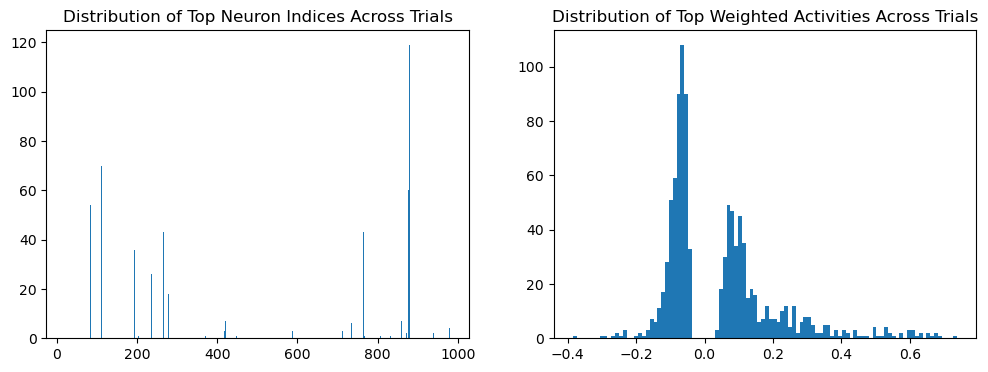

In [54]:
fig, axs = plt.subplots(1,2, figsize=(12,4))
axs[0].hist(np.array(top_idxs).flatten(), bins=1000)
axs[0].set_title('Distribution of Top Neuron Indices Across Trials')
axs[1].hist(np.array(top_values).flatten(), bins=100)
axs[1].set_title('Distribution of Top Weighted Activities Across Trials')
plt.show()


In [55]:
top_idxs_flat = np.array(top_idxs).flatten()
unique, counts = np.unique(top_idxs_flat, return_counts=True)
top_neuron_counts = dict(zip(unique, counts))
print("Top Neuron Counts:", top_neuron_counts)

Top Neuron Counts: {22: 51, 28: 3, 80: 1, 84: 54, 112: 70, 123: 72, 133: 14, 176: 1, 190: 2, 194: 36, 204: 1, 205: 33, 218: 1, 236: 26, 252: 1, 258: 3, 266: 43, 278: 18, 293: 10, 318: 1, 330: 34, 333: 1, 371: 1, 399: 77, 418: 3, 421: 7, 422: 1, 448: 1, 457: 1, 475: 1, 479: 3, 527: 18, 588: 3, 649: 14, 664: 7, 671: 2, 697: 8, 709: 12, 711: 14, 712: 3, 713: 28, 735: 6, 765: 43, 767: 1, 807: 1, 825: 13, 828: 10, 832: 1, 845: 2, 860: 7, 872: 2, 877: 60, 879: 119, 903: 7, 905: 3, 938: 1, 939: 2, 945: 8, 950: 10, 975: 20, 980: 4}


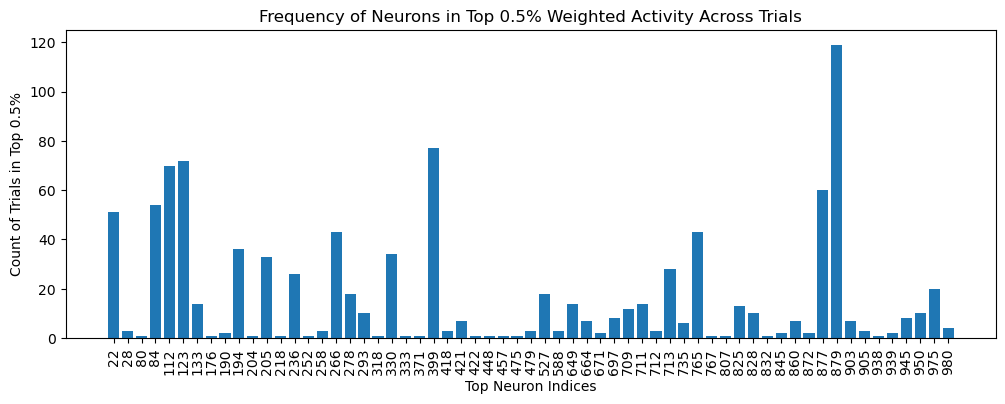

In [58]:
# bar plot of the top neurons
plt.figure(figsize=(12,4))
plt.bar(range(len(top_neuron_counts)), list(top_neuron_counts.values()))
plt.xticks(ticks=range(len(top_neuron_counts)), labels=top_neuron_counts.keys(), rotation=90)
plt.xlabel('Top Neuron Indices')
plt.ylabel('Count of Trials in Top 0.5%')
plt.title('Frequency of Neurons in Top 0.5% Weighted Activity Across Trials')
plt.show()

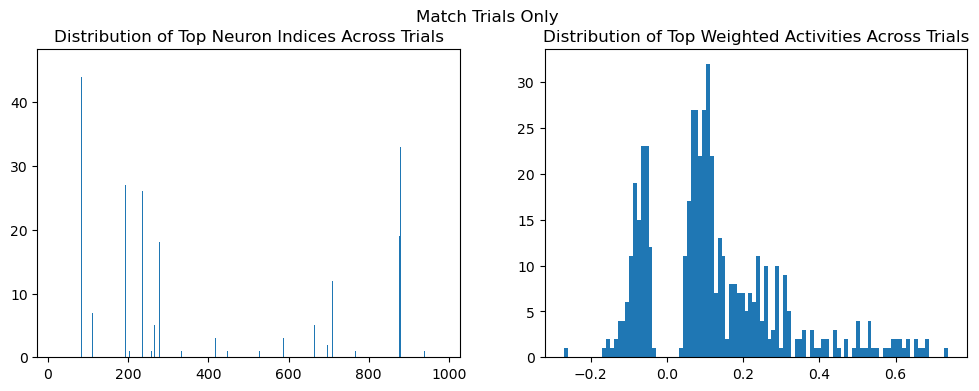

In [59]:
# how about just match trials?

match_trial_idxs = np.where(trial_labels_match[:,1] == 1)[0]
top_idxs_match = [top_idxs[i] for i in match_trial_idxs]
top_values_match = [top_values[i] for i in match_trial_idxs]

fig, axs = plt.subplots(1,2, figsize=(12,4))
axs[0].hist(np.array(top_idxs_match).flatten(), bins=1000)
axs[0].set_title('Distribution of Top Neuron Indices Across Trials')
axs[1].hist(np.array(top_values_match).flatten(), bins=100)
axs[1].set_title('Distribution of Top Weighted Activities Across Trials')
plt.suptitle('Match Trials Only')
plt.show()

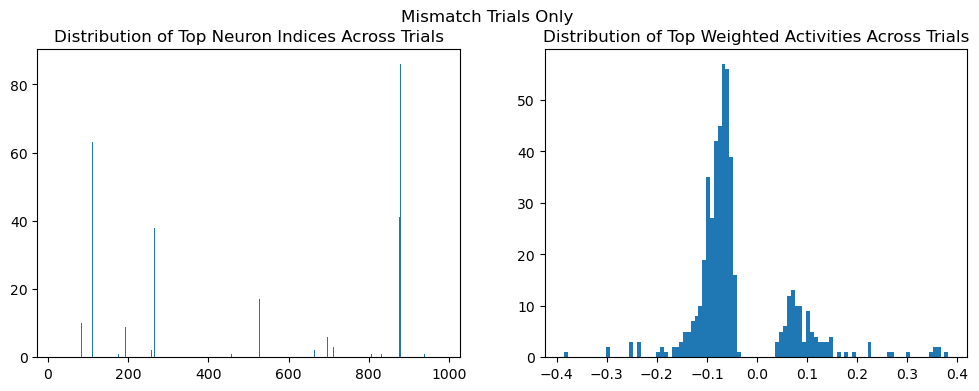

In [60]:
# now mismatch

mismatch_trial_idxs = np.where(trial_labels_match[:,1] == -1)[0]
top_idxs_mismatch = [top_idxs[i] for i in mismatch_trial_idxs]
top_values_mismatch = [top_values[i] for i in mismatch_trial_idxs]

fig, axs = plt.subplots(1,2, figsize=(12,4))
axs[0].hist(np.array(top_idxs_mismatch).flatten(), bins=1000)
axs[0].set_title('Distribution of Top Neuron Indices Across Trials')
axs[1].hist(np.array(top_values_mismatch).flatten(), bins=100)
axs[1].set_title('Distribution of Top Weighted Activities Across Trials')
plt.suptitle('Mismatch Trials Only')
plt.show()

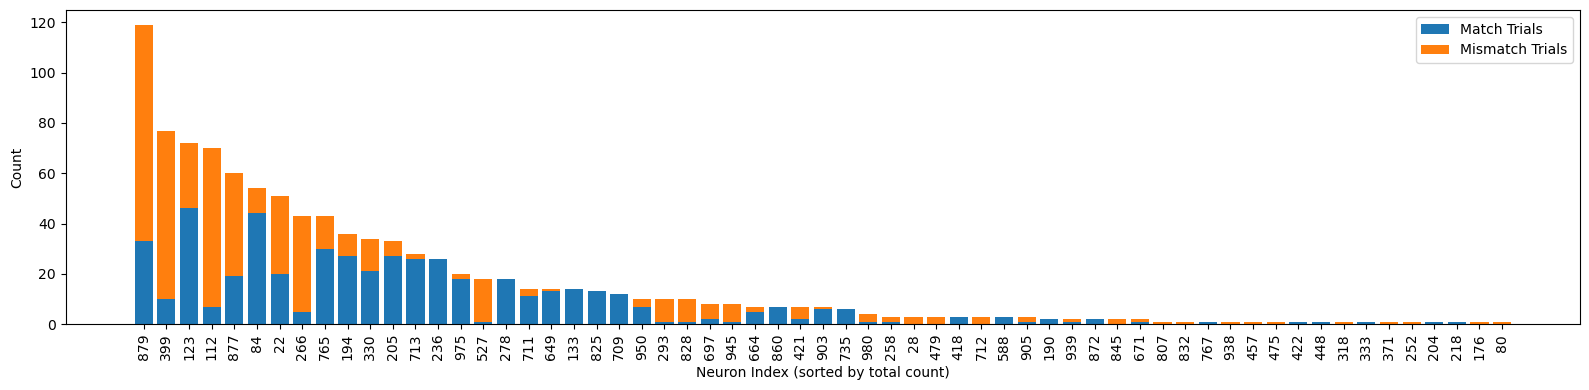

In [61]:
# how different are the top neurons for match vs mismatch trials?

# Flatten + count
top_idxs_match_flat = np.array(top_idxs_match).flatten()
match_unique, match_counts = np.unique(top_idxs_match_flat, return_counts=True)
top_neuron_counts_match = dict(zip(match_unique, match_counts))

top_idxs_mismatch_flat = np.array(top_idxs_mismatch).flatten()
mismatch_unique, mismatch_counts = np.unique(top_idxs_mismatch_flat, return_counts=True)
top_neuron_counts_mismatch = dict(zip(mismatch_unique, mismatch_counts))

# Combine neuron indices
all_neurons = sorted(set(top_neuron_counts_match) | set(top_neuron_counts_mismatch))

# Get aligned values
match_vals = np.array([top_neuron_counts_match.get(n, 0) for n in all_neurons])
mismatch_vals = np.array([top_neuron_counts_mismatch.get(n, 0) for n in all_neurons])

# --- SORT by total count (descending) ---
totals = match_vals + mismatch_vals
order = np.argsort(totals)[::-1]

all_neurons = np.array(all_neurons)[order]
match_vals = match_vals[order]
mismatch_vals = mismatch_vals[order]

# Condensed x positions
x_pos = np.arange(len(all_neurons))

# Plot
plt.figure(figsize=(16, 4))

plt.bar(x_pos, match_vals, label='Match Trials')
plt.bar(x_pos, mismatch_vals, bottom=match_vals, label='Mismatch Trials')

plt.xticks(x_pos, all_neurons, rotation=90)

plt.xlabel('Neuron Index (sorted by total count)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

In [62]:
all_neurons

array([879, 399, 123, 112, 877,  84,  22, 266, 765, 194, 330, 205, 713,
       236, 975, 527, 278, 711, 649, 133, 825, 709, 950, 293, 828, 697,
       945, 664, 860, 421, 903, 735, 980, 258,  28, 479, 418, 712, 588,
       905, 190, 939, 872, 845, 671, 807, 832, 767, 938, 457, 475, 422,
       448, 318, 333, 371, 252, 204, 218, 176,  80])

### plot some firing rates

In [ ]:
# neural data
_, rates_data_match = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= "balance_match",
                                            all_models_dir = all_models_dir, load_LFP=False)
_, rates_data_stim = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= "balance_stim",
                                            all_models_dir = all_models_dir, load_LFP=False)
rates_data = np.concatenate((rates_data_match, rates_data_stim), axis=0)
print(rates_data.shape)

# behavioral data
trial_labels_match, trial_perfs_match, trial_outputs_match = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                    other_labels="balance_match",
                                                    all_models_dir=all_models_dir)
trial_labels_stim, trial_perfs_stim, trial_outputs_stim = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                    other_labels="balance_stim",
                                                    all_models_dir=all_models_dir)
trial_labels = np.concatenate((trial_labels_match, trial_labels_stim), axis=0)
trial_perfs = np.concatenate((trial_perfs_match, trial_perfs_stim), axis=0)

settings = ld.load_settings_rate_data(model_name, condn_phrase, condn_num,
                                      other_labels="balance_stim",
                                      all_models_dir=all_models_dir)

load_tuning = rn.calc_load_tuning(model_name, condn_phrase, condn_num, 
                                other_labels = "balance_match",
                                all_models_dir=all_models_dir)

stim1_tuning = np.load(os.path.join(model_dir, 'stim1_tuning_nonparametric.npz'))['stim1_tuning']

(536, 1000, 450)


/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils/rate_neuron_utils.py:610: RuntimeWarning: Mean of empty slice
  g1_mean = np.nanmean(rates_data[idxs_one,:], axis=0)
/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils/rate_neuron_utils.py:612: RuntimeWarning: Mean of empty slice
  g2_mean = np.nanmean(rates_data[idxs_two,:], axis=0)
/tmp/ipykernel_803171/1267441476.py:50: RuntimeWarning: Mean of empty slice
  stim3_pref_mean = np.nanmean(neuron_rates[stim3_pref_load3_idx, :], axis=0)
/tmp/ipykernel_803171/1267441476.py:51: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  stim3_pref_sem = scipy.stats.sem(neuron_rates[stim3_pref_load3_idx, :], axis=0, nan_policy='omit')
/tmp/ipykernel_803171/1267441476.py:52: RuntimeWarning: Mean of empty slice
  stim2_pref_mean = np.nanmean(neuron_rates[stim2_pref_load3_idx, :

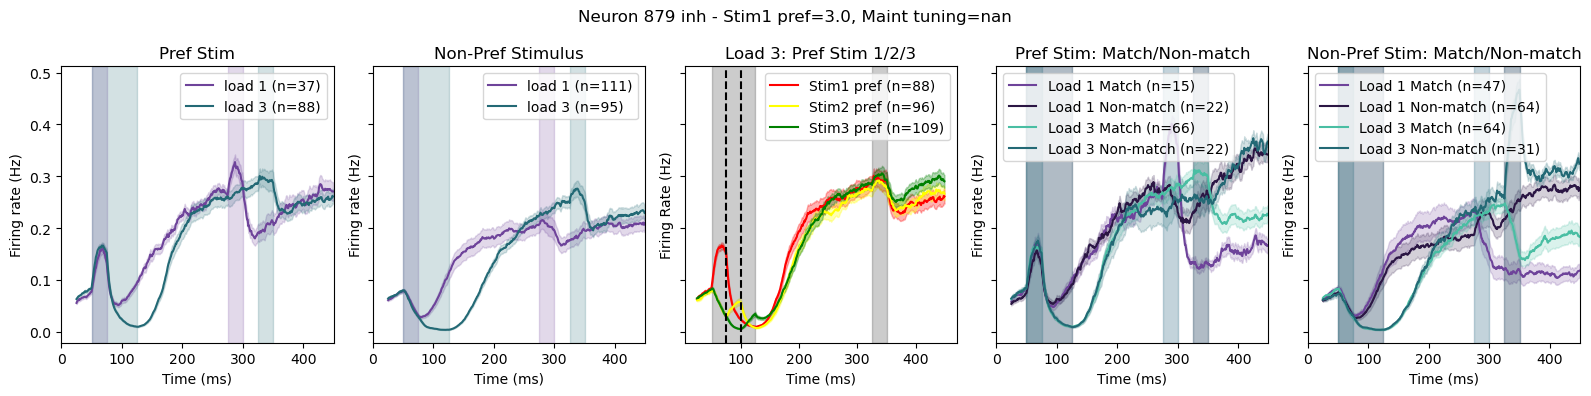

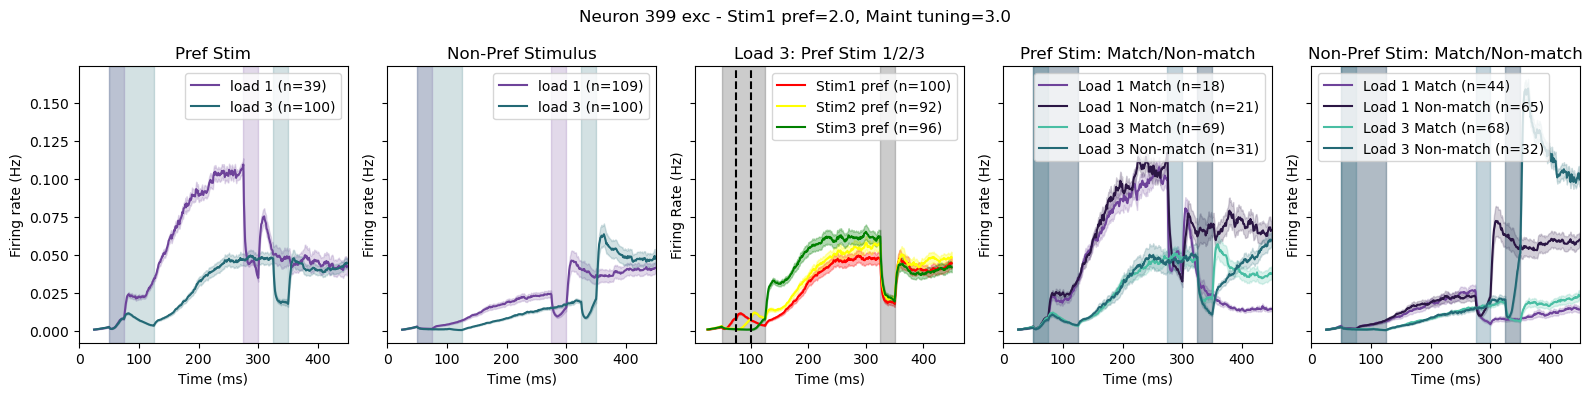

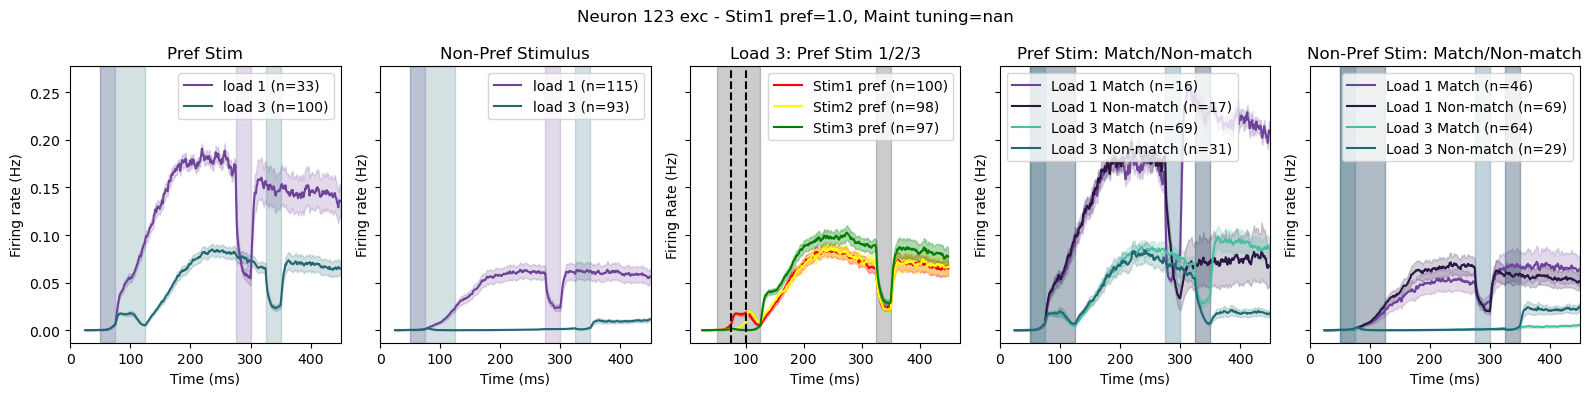

Neuron 112 is not significantly tuned to any stim1. Skipping subplot 1.


/tmp/ipykernel_803171/1267441476.py:51: SmallSampleWarning: All axis-slices of one or more sample arguments are too small; all elements of returned arrays will be NaN. See documentation for sample size requirements.
  stim3_pref_sem = scipy.stats.sem(neuron_rates[stim3_pref_load3_idx, :], axis=0, nan_policy='omit')
/tmp/ipykernel_803171/1267441476.py:53: SmallSampleWarning: All axis-slices of one or more sample arguments are too small; all elements of returned arrays will be NaN. See documentation for sample size requirements.
  stim2_pref_sem = scipy.stats.sem(neuron_rates[stim2_pref_load3_idx, :], axis=0, nan_policy='omit')
/tmp/ipykernel_803171/1267441476.py:55: SmallSampleWarning: All axis-slices of one or more sample arguments are too small; all elements of returned arrays will be NaN. See documentation for sample size requirements.
  stim1_pref_sem = scipy.stats.sem(neuron_rates[stim1_pref_load3_idx, :], axis=0, nan_policy='omit')
/home/nuttidalab/Documents/renee/spikeRNN/analysi

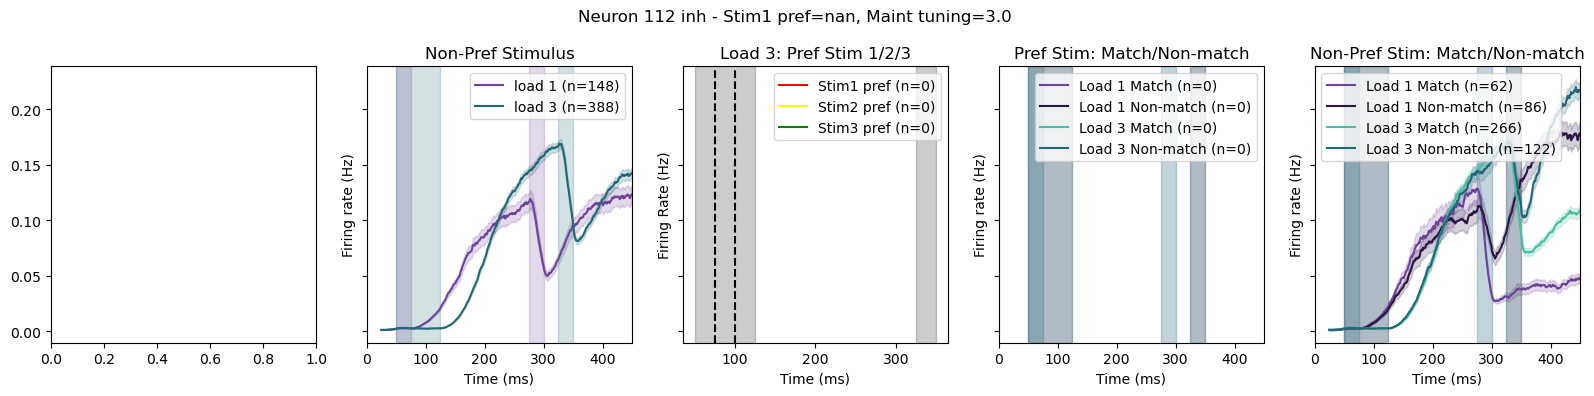

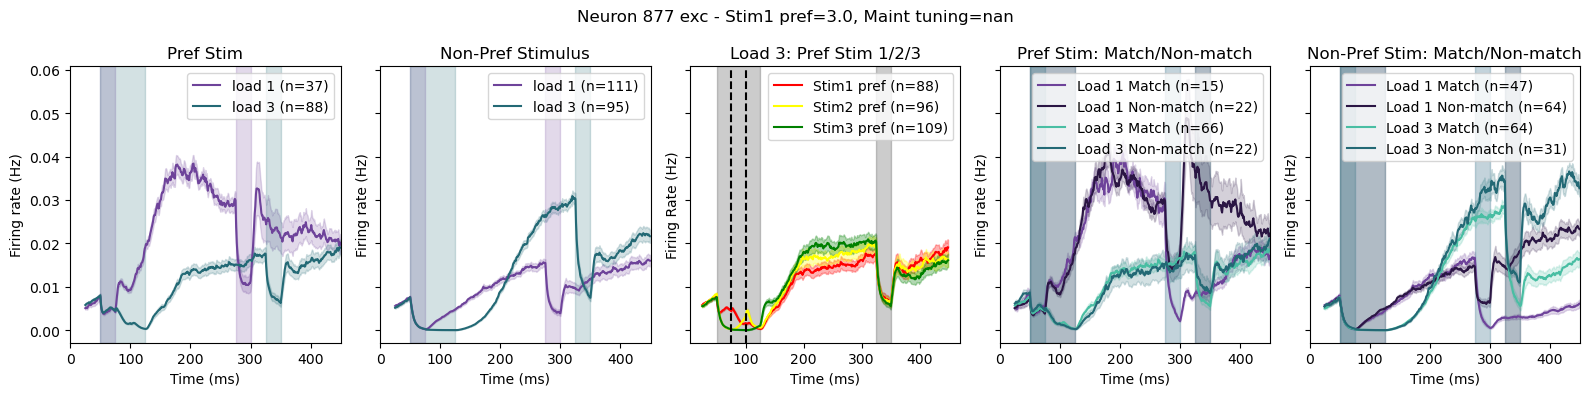

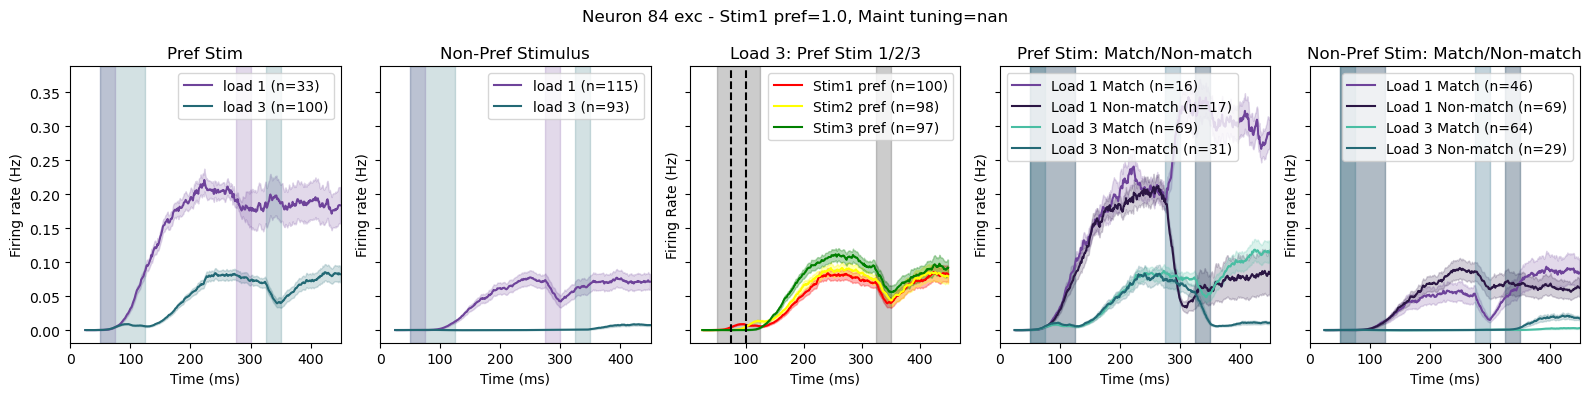

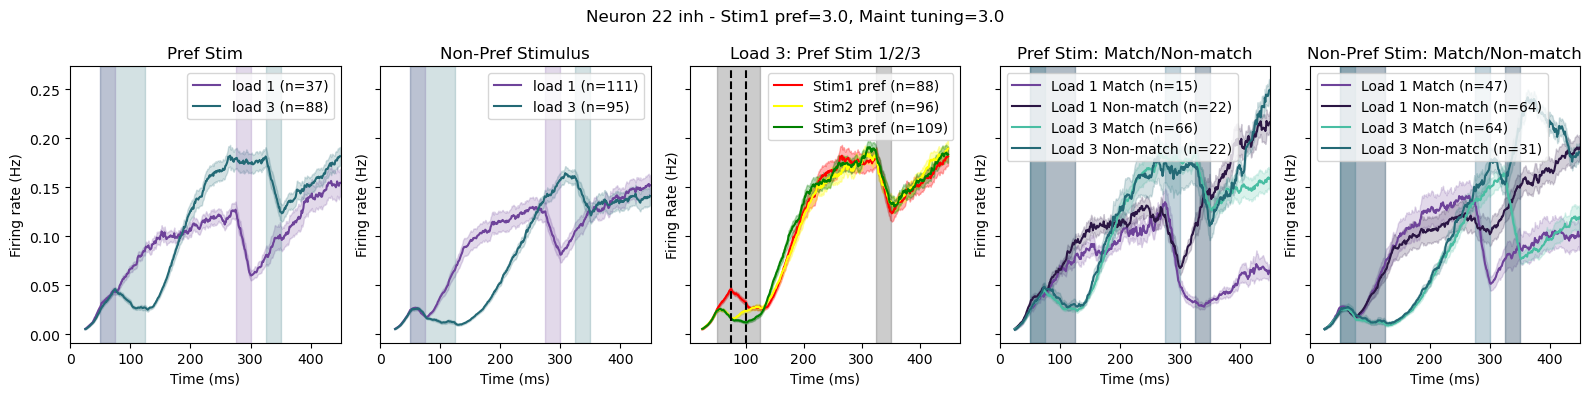

Neuron 266 is not significantly tuned to any stim1. Skipping subplot 1.


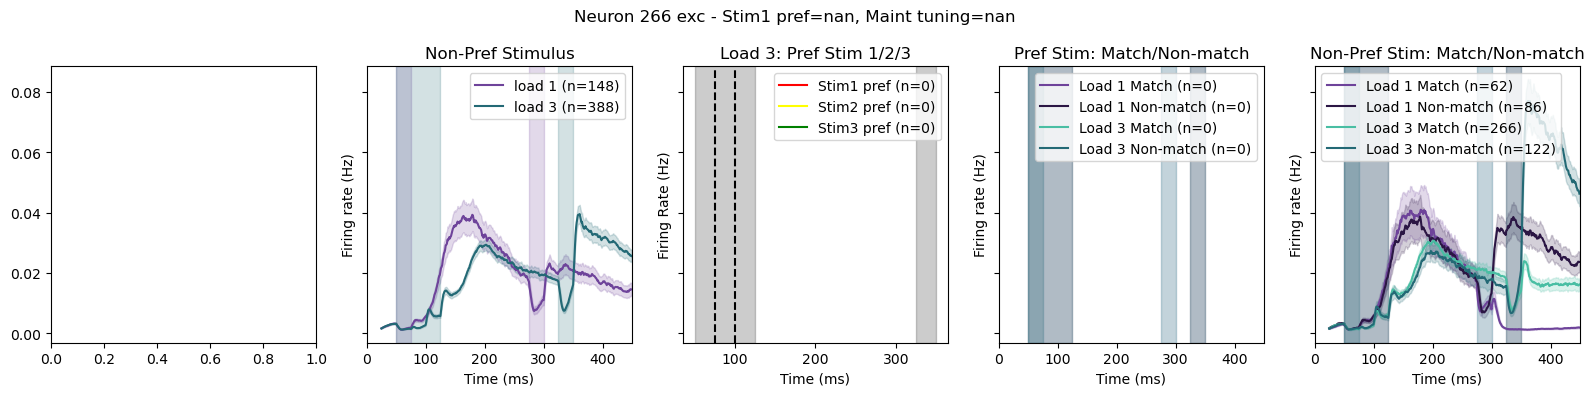

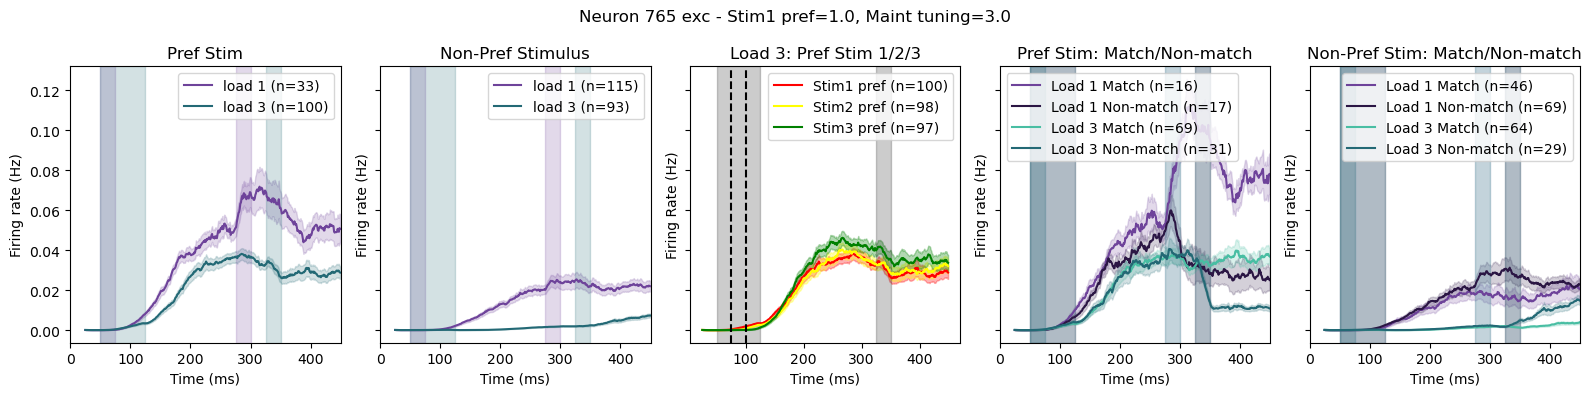

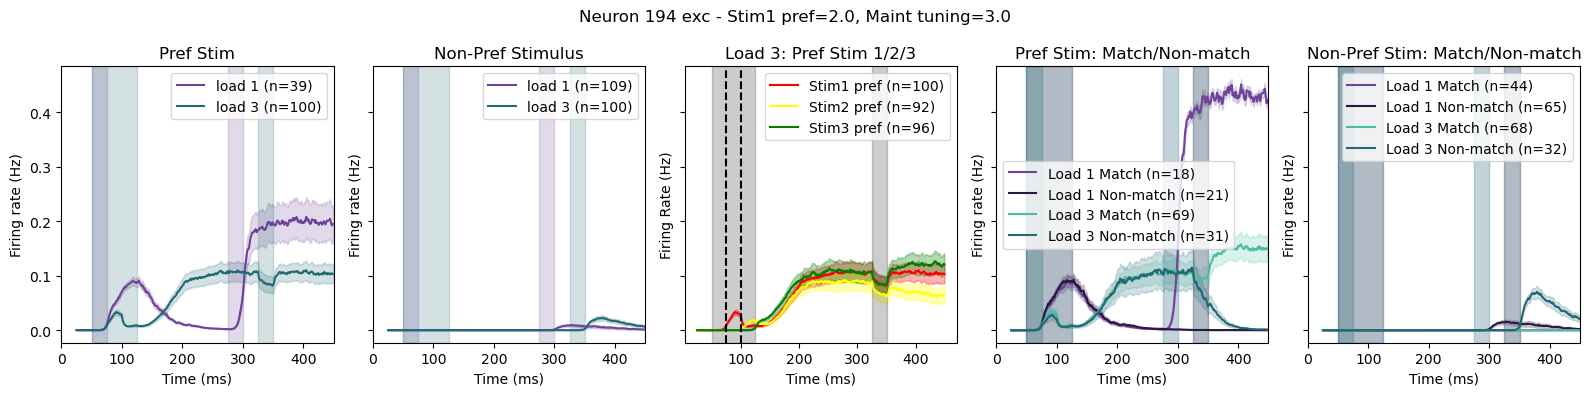

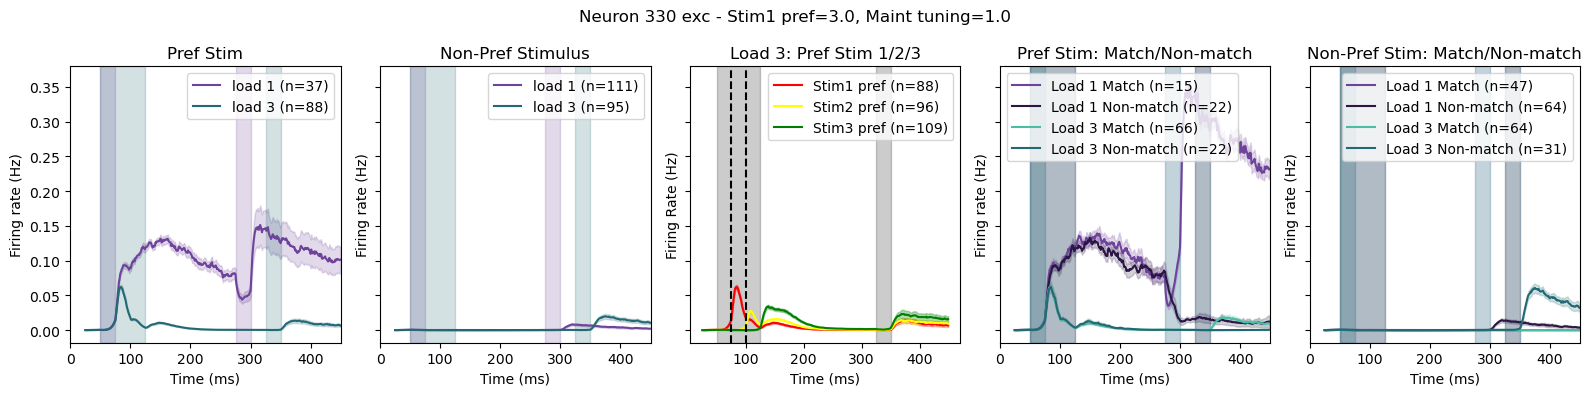

Neuron 205 is not significantly tuned to any stim1. Skipping subplot 1.


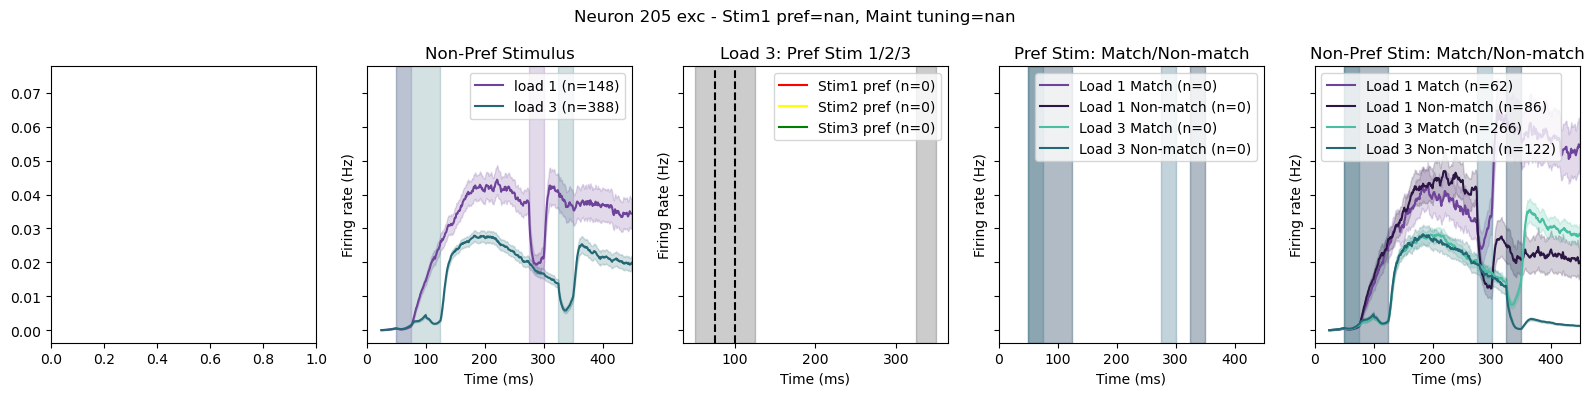

In [70]:
# let's look at the top 12 neurons that appear most frequently in the top .5% across all trials
top_idxs = all_neurons[:12]
exc_ind, inh_ind = ld.get_celltype_label(model_name, all_models_dir=all_models_dir)

# let's plot these high output neurons
importlib.reload(rn)

for neuron_idx in top_idxs:

    stim1_pref = stim1_tuning[neuron_idx]
    maint_pref = load_tuning[neuron_idx]

    neuron_rates = rates_data[:, neuron_idx, :]
    neuron_rates[:, :25] = np.nan # mask the first 25 time bins to avoid noise; trials x time

    _, colors = rn.get_trialtype_colors()

    t_range = np.arange(rates_data.shape[2])

    fig, axs = plt.subplots(1,5, figsize=(16,4), sharey=True)
    axs = axs.flatten()
    plt.suptitle(f'Neuron {neuron_idx} {["exc" if neuron_idx in exc_ind else "inh"][0]} - Stim1 pref={stim1_pref}, Maint tuning={maint_pref}')

    #subplot1: stim1 = preferred, load 1 vs load 3
    if np.isnan(stim1_pref):
        print(f'Neuron {neuron_idx} is not significantly tuned to any stim1. Skipping subplot 1.')
        stim1_pref_load1_idx = np.array([], dtype=int)
        stim1_pref_load3_idx = np.array([], dtype=int)
    else:
        stim1_pref_load1_idx = np.where((trial_labels[:, 2] == stim1_pref) & (trial_labels[:, 0] == 1))[0]
        stim1_pref_load3_idx = np.where((trial_labels[:, 2] == stim1_pref) & (trial_labels[:, 0] == 3))[0]

        rn.plot_rates(neuron_rates, stim1_pref_load1_idx, stim1_pref_load3_idx, 
                    settings, trial_labels, title=f'Pref Stim', 
                    labels_one = 'load 1', labels_two = 'load 3', ax=axs[0], colors=None)


    # subplot2: stim1 = nonpreferred, load 1 vs load 3
    nonpref_idx = np.where(np.all(trial_labels[:, 2:5] != stim1_pref, axis=1))[0]
    nonpref_load1_idx = np.intersect1d(nonpref_idx, np.where(trial_labels[:, 0] == 1)[0])
    nonpref_load3_idx = np.intersect1d(nonpref_idx, np.where(trial_labels[:, 0] == 3)[0])
    rn.plot_rates(neuron_rates, nonpref_load1_idx, nonpref_load3_idx,
                settings, trial_labels, title='Non-Pref Stimulus', 
                labels_one = 'load 1', labels_two = 'load 3', ax=axs[1], colors=None)

    # subplot3: load 3-- preferred as stim1 vs stim2 vs stim3
    stim1_pref_load3_idx = np.where((trial_labels[:, 2] == stim1_pref) & (trial_labels[:, 0] == 3))[0]
    stim2_pref_load3_idx = np.where((trial_labels[:, 3] == stim1_pref) & (trial_labels[:, 0] == 3))[0]
    stim3_pref_load3_idx = np.where((trial_labels[:, 4] == stim1_pref) & (trial_labels[:, 0] == 3))[0]
    stim3_pref_mean = np.nanmean(neuron_rates[stim3_pref_load3_idx, :], axis=0)
    stim3_pref_sem = scipy.stats.sem(neuron_rates[stim3_pref_load3_idx, :], axis=0, nan_policy='omit')
    stim2_pref_mean = np.nanmean(neuron_rates[stim2_pref_load3_idx, :], axis=0)
    stim2_pref_sem = scipy.stats.sem(neuron_rates[stim2_pref_load3_idx, :], axis=0, nan_policy='omit')
    stim1_pref_mean = np.nanmean(neuron_rates[stim1_pref_load3_idx, :], axis=0)
    stim1_pref_sem = scipy.stats.sem(neuron_rates[stim1_pref_load3_idx, :], axis=0, nan_policy='omit')
    axs[2].plot(t_range, stim1_pref_mean, color='r', label=f'Stim1 pref (n={len(stim1_pref_load3_idx)})')
    axs[2].fill_between(t_range, stim1_pref_mean - stim1_pref_sem, stim1_pref_mean + stim1_pref_sem, color='r', alpha=0.3)  
    axs[2].plot(t_range, stim2_pref_mean, color='yellow', label=f'Stim2 pref (n={len(stim2_pref_load3_idx)})')
    axs[2].fill_between(t_range, stim2_pref_mean - stim2_pref_sem, stim2_pref_mean + stim2_pref_sem, color='yellow', alpha=0.3)
    axs[2].plot(t_range, stim3_pref_mean, color='g', label=f'Stim3 pref (n={len(stim3_pref_load3_idx)})')
    axs[2].fill_between(t_range, stim3_pref_mean - stim3_pref_sem, stim3_pref_mean + stim3_pref_sem, color='g', alpha=0.3)
    axs[2].axvspan(settings['stim_on'], settings['stim_on'] + settings['stim_dur']*3, color='k', alpha=0.2)
    axs[2].axvspan(settings['stim_on'] + settings['stim_dur']*3 + settings['delay'], settings['stim_on'] + settings['stim_dur']*3 + settings['delay'] + settings['stim_dur'], color='k', alpha=0.2)
    axs[2].axvline(settings['stim_on'] + settings['stim_dur']*2, color='k', linestyle='--')
    axs[2].axvline(settings['stim_on'] + settings['stim_dur']*1, color='k', linestyle='--')
    axs[2].legend()
    axs[2].set_title('Load 3: Pref Stim 1/2/3')
    axs[2].set_xlabel('Time (ms)'); axs[2].set_ylabel('Firing Rate (Hz)')
    
    # subplot4: stim1=preferred, stim2=match vs non-match (only load 1 and 3)
    stim1_pref_load1_idx_match = np.intersect1d(stim1_pref_load1_idx, np.where(trial_labels[:, 1] == 1)[0]) # match trials
    stim1_pref_load1_idx_nonmatch = np.intersect1d(stim1_pref_load1_idx, np.where(trial_labels[:, 1] == -1)[0]) # non-match trials
    stim1_pref_load3_idx_match = np.intersect1d(stim1_pref_load3_idx, np.where(trial_labels[:, 1] == 1)[0]) # match trials
    stim1_pref_load3_idx_nonmatch = np.intersect1d(stim1_pref_load3_idx, np.where(trial_labels[:, 1] == -1)[0]) # non-match trials
    rn.plot_rates(neuron_rates, stim1_pref_load1_idx_match, stim1_pref_load1_idx_nonmatch, settings, trial_labels,
                  labels_one='Load 1 Match', labels_two='Load 1 Non-match', colors=[colors[0],colors[1]], ax=axs[3],
                  title='Pref Stim: Match/Non-match')
    rn.plot_rates(neuron_rates, stim1_pref_load3_idx_match, stim1_pref_load3_idx_nonmatch, settings, trial_labels,
                  labels_one='Load 3 Match', labels_two='Load 3 Non-match', colors=[colors[3],colors[2]], ax=axs[3],
                  title='Pref Stim: Match/Non-match')
    
    # subplot5: stim1=nonpreferred, stim2=match vs non-match (only load 1 and 3)
    nonpref_load1_idx_match = np.intersect1d(nonpref_load1_idx, np.where(trial_labels[:, 1] == 1)[0]) # match trials
    nonpref_load1_idx_nonmatch = np.intersect1d(nonpref_load1_idx, np.where(trial_labels[:, 1] == -1)[0]) # non-match trials
    nonpref_load3_idx_match = np.intersect1d(nonpref_load3_idx, np.where(trial_labels[:, 1] == 1)[0]) # match trials
    nonpref_load3_idx_nonmatch = np.intersect1d(nonpref_load3_idx, np.where(trial_labels[:, 1] == -1)[0]) # non-match trials
    rn.plot_rates(neuron_rates, nonpref_load1_idx_match, nonpref_load1_idx_nonmatch, settings, trial_labels,
                  labels_one='Load 1 Match', labels_two='Load 1 Non-match', colors=[colors[0],colors[1]], ax=axs[4],
                  title='Non-Pref Stim: Match/Non-match')
    rn.plot_rates(neuron_rates, nonpref_load3_idx_match, nonpref_load3_idx_nonmatch, settings, trial_labels,
                  labels_one='Load 3 Match', labels_two='Load 3 Non-match', colors=[colors[3],colors[2]], ax=axs[4],
                  title='Non-Pref Stim: Match/Non-match')

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_803171/2024732917.py:50: RuntimeWarning: Mean of empty slice
  stim3_pref_mean = np.nanmean(neuron_rates[stim3_pref_load3_idx, :], axis=0)
/tmp/ipykernel_803171/2024732917.py:51: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  stim3_pref_sem = scipy.stats.sem(neuron_rates[stim3_pref_load3_idx, :], axis=0, nan_policy='omit')
/tmp/ipykernel_803171/2024732917.py:52: RuntimeWarning: Mean of empty slice
  stim2_pref_mean = np.nanmean(neuron_rates[stim2_pref_load3_idx, :], axis=0)
/tmp/ipykernel_803171/2024732917.py:53: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  stim2_pref_sem = scipy.stats.sem(neuron_rates[stim2_pref_load3_idx, :], axis=0, n

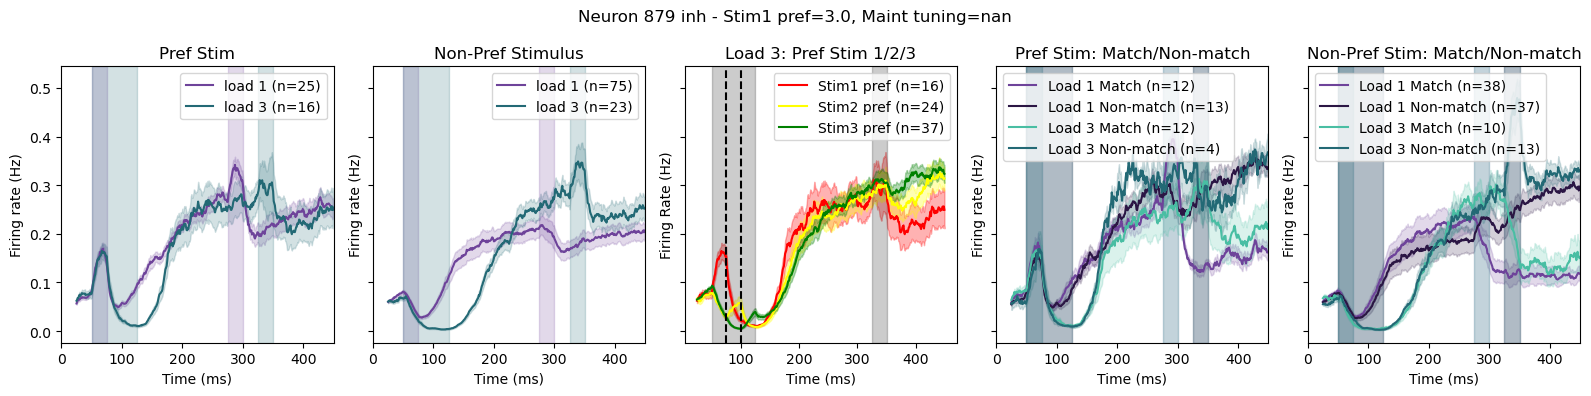

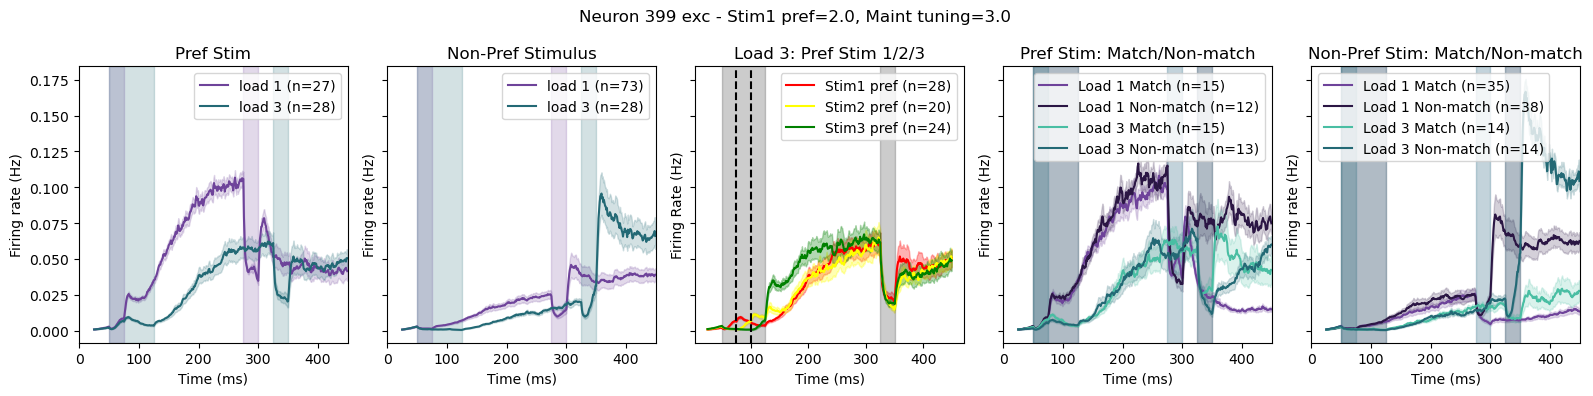

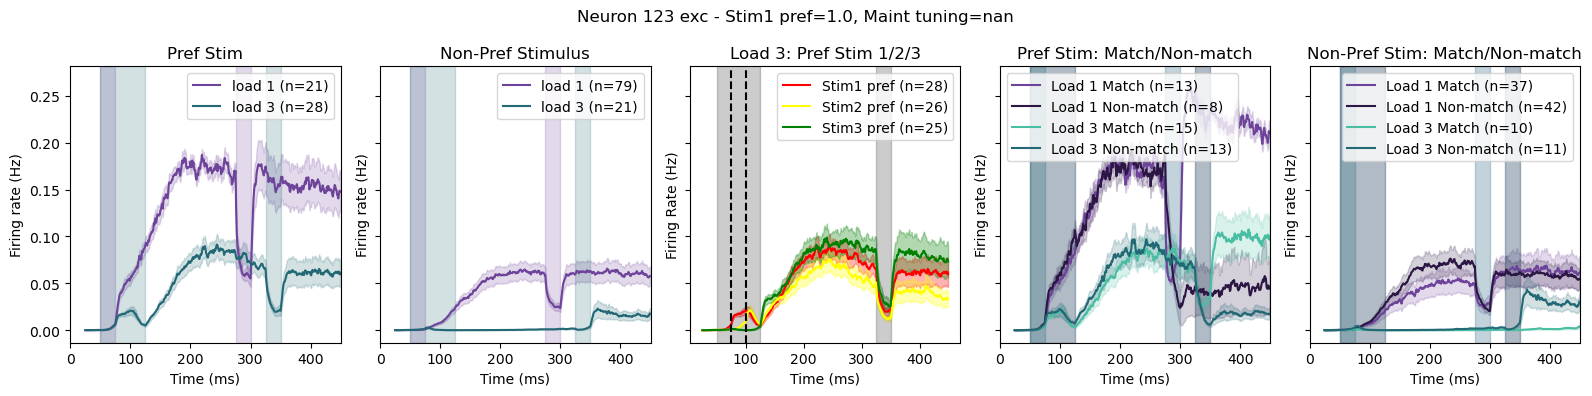

Neuron 112 is not significantly tuned to any stim1. Skipping subplot 1.


/tmp/ipykernel_803171/2024732917.py:51: SmallSampleWarning: All axis-slices of one or more sample arguments are too small; all elements of returned arrays will be NaN. See documentation for sample size requirements.
  stim3_pref_sem = scipy.stats.sem(neuron_rates[stim3_pref_load3_idx, :], axis=0, nan_policy='omit')
/tmp/ipykernel_803171/2024732917.py:53: SmallSampleWarning: All axis-slices of one or more sample arguments are too small; all elements of returned arrays will be NaN. See documentation for sample size requirements.
  stim2_pref_sem = scipy.stats.sem(neuron_rates[stim2_pref_load3_idx, :], axis=0, nan_policy='omit')
/tmp/ipykernel_803171/2024732917.py:55: SmallSampleWarning: All axis-slices of one or more sample arguments are too small; all elements of returned arrays will be NaN. See documentation for sample size requirements.
  stim1_pref_sem = scipy.stats.sem(neuron_rates[stim1_pref_load3_idx, :], axis=0, nan_policy='omit')


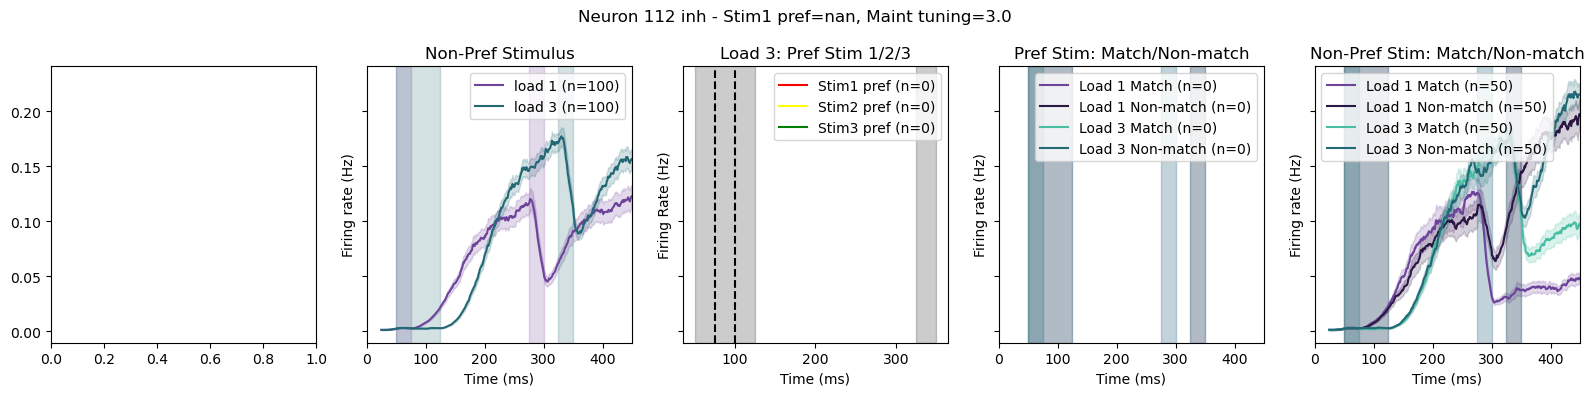

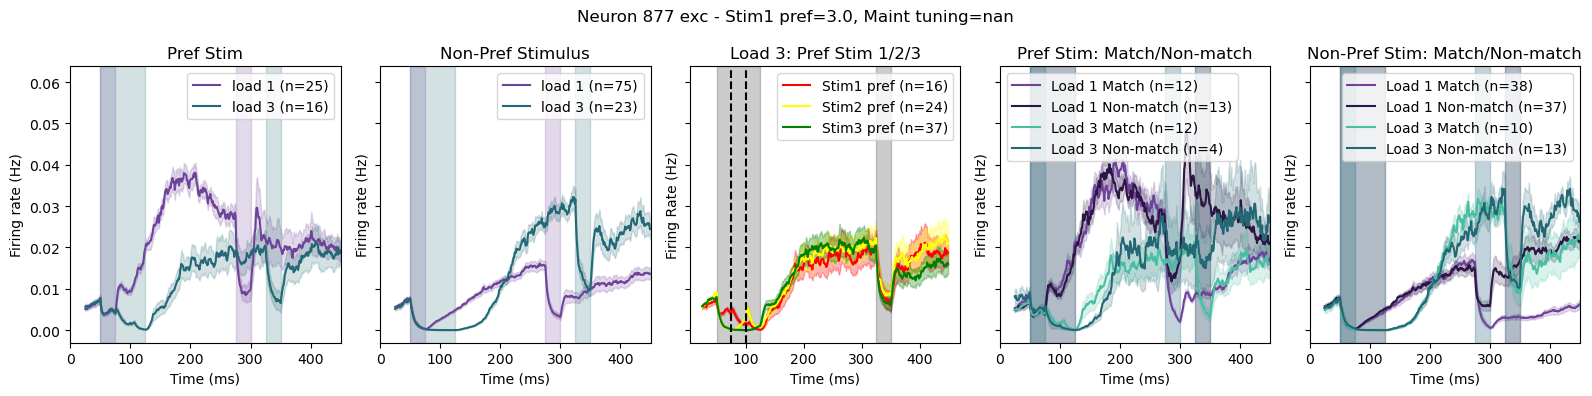

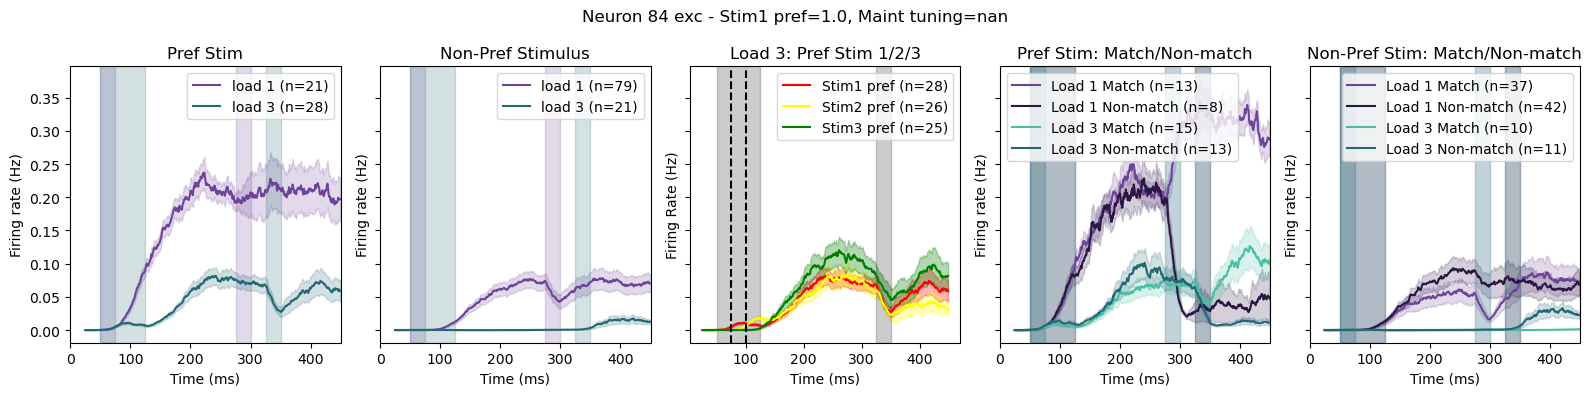

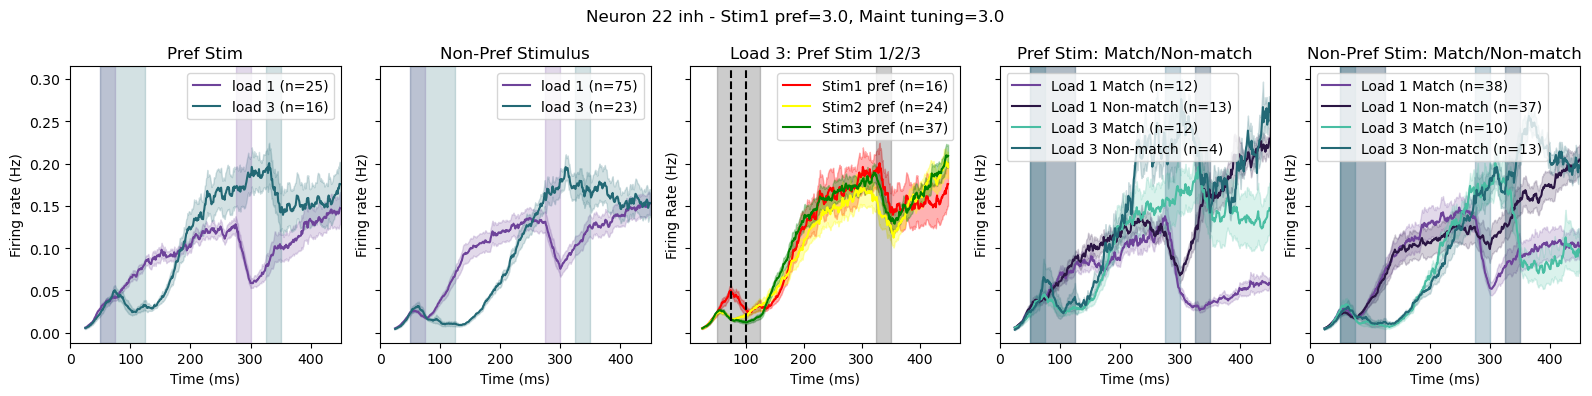

Neuron 266 is not significantly tuned to any stim1. Skipping subplot 1.


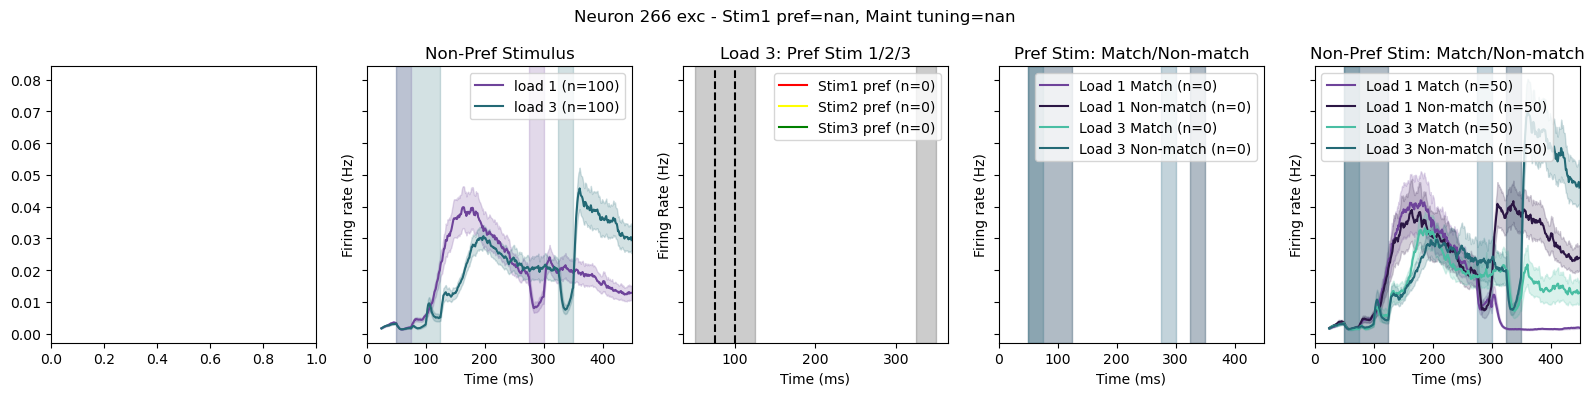

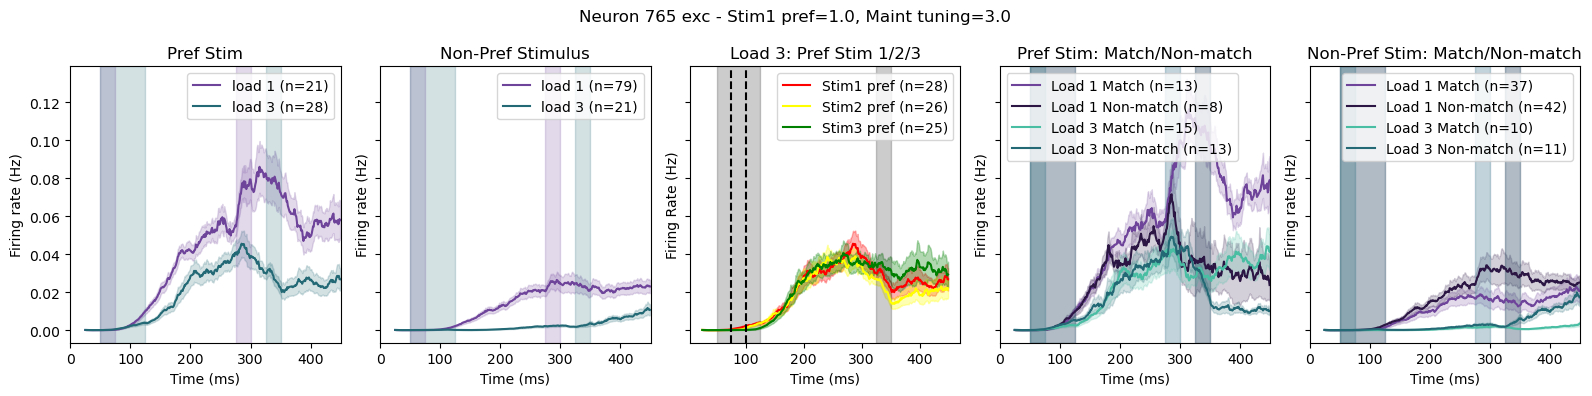

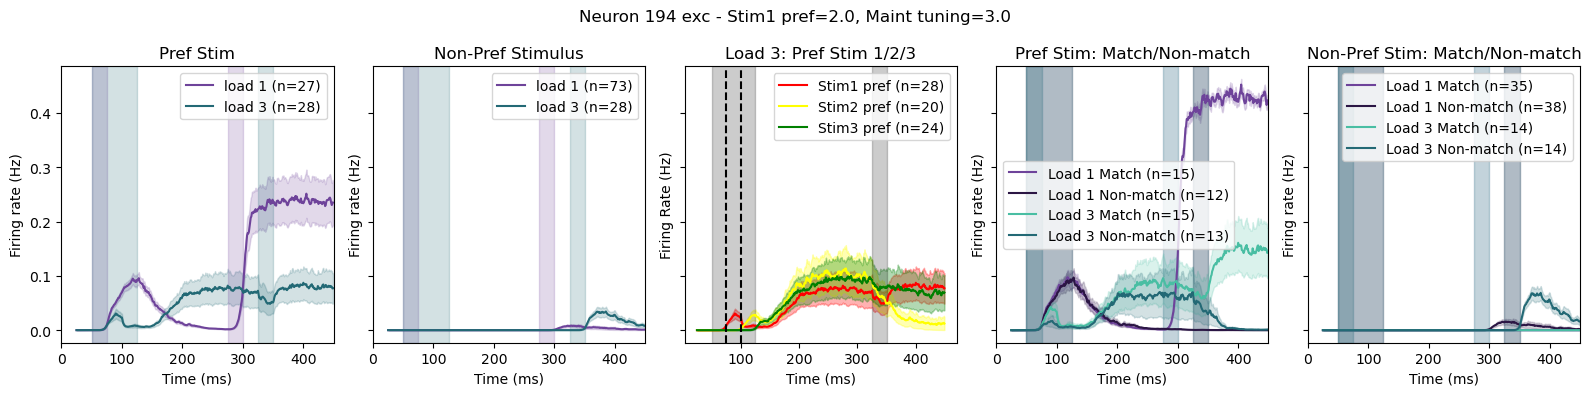

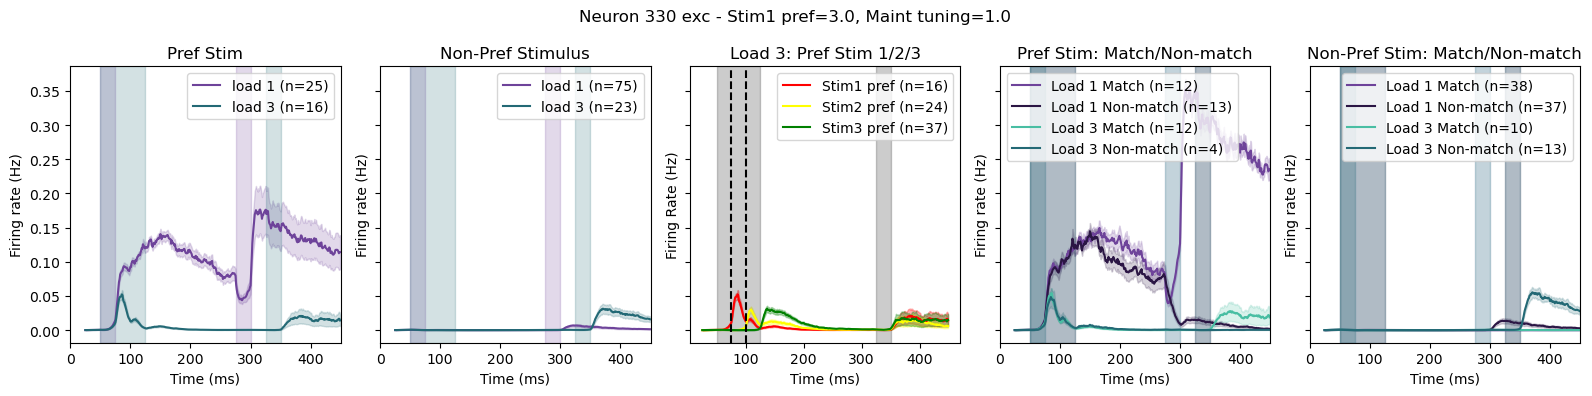

Neuron 205 is not significantly tuned to any stim1. Skipping subplot 1.


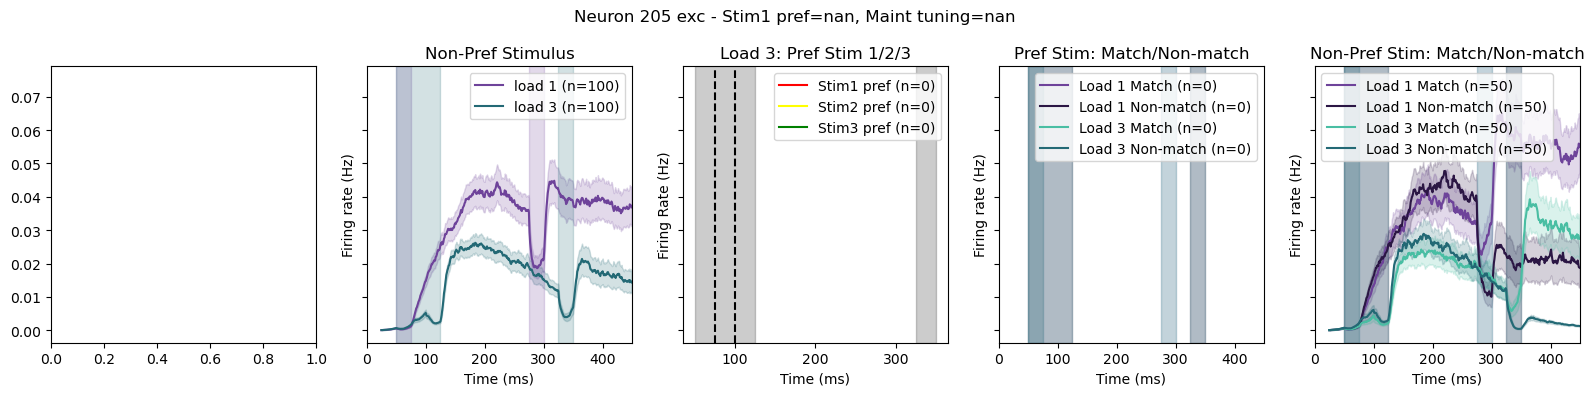

In [71]:
# let's look at the top 12 neurons that appear most frequently in the top .5% across all trials -- only balance match set
top_idxs = all_neurons[:12]
exc_ind, inh_ind = ld.get_celltype_label(model_name, all_models_dir=all_models_dir)

# let's plot these high output neurons
importlib.reload(rn)

for neuron_idx in top_idxs:

    stim1_pref = stim1_tuning[neuron_idx]
    maint_pref = load_tuning[neuron_idx]

    neuron_rates = rates_data_match[:, neuron_idx, :]
    neuron_rates[:, :25] = np.nan # mask the first 25 time bins to avoid noise; trials x time

    _, colors = rn.get_trialtype_colors()

    t_range = np.arange(rates_data_match.shape[2])

    fig, axs = plt.subplots(1,5, figsize=(16,4), sharey=True)
    axs = axs.flatten()
    plt.suptitle(f'Neuron {neuron_idx} {["exc" if neuron_idx in exc_ind else "inh"][0]} - Stim1 pref={stim1_pref}, Maint tuning={maint_pref}')

    #subplot1: stim1 = preferred, load 1 vs load 3
    if np.isnan(stim1_pref):
        print(f'Neuron {neuron_idx} is not significantly tuned to any stim1. Skipping subplot 1.')
        stim1_pref_load1_idx = np.array([], dtype=int)
        stim1_pref_load3_idx = np.array([], dtype=int)
    else:
        stim1_pref_load1_idx = np.where((trial_labels_match[:, 2] == stim1_pref) & (trial_labels_match[:, 0] == 1))[0]
        stim1_pref_load3_idx = np.where((trial_labels_match[:, 2] == stim1_pref) & (trial_labels_match[:, 0] == 3))[0]

        rn.plot_rates(neuron_rates, stim1_pref_load1_idx, stim1_pref_load3_idx, 
                    settings, trial_labels_match, title=f'Pref Stim', 
                    labels_one = 'load 1', labels_two = 'load 3', ax=axs[0], colors=None)


    # subplot2: stim1 = nonpreferred, load 1 vs load 3
    nonpref_idx = np.where(np.all(trial_labels_match[:, 2:5] != stim1_pref, axis=1))[0]
    nonpref_load1_idx = np.intersect1d(nonpref_idx, np.where(trial_labels_match[:, 0] == 1)[0])
    nonpref_load3_idx = np.intersect1d(nonpref_idx, np.where(trial_labels_match[:, 0] == 3)[0])
    rn.plot_rates(neuron_rates, nonpref_load1_idx, nonpref_load3_idx,
                settings, trial_labels_match, title='Non-Pref Stimulus', 
                labels_one = 'load 1', labels_two = 'load 3', ax=axs[1], colors=None)

    # subplot3: load 3-- preferred as stim1 vs stim2 vs stim3
    stim1_pref_load3_idx = np.where((trial_labels_match[:, 2] == stim1_pref) & (trial_labels_match[:, 0] == 3))[0]
    stim2_pref_load3_idx = np.where((trial_labels_match[:, 3] == stim1_pref) & (trial_labels_match[:, 0] == 3))[0]
    stim3_pref_load3_idx = np.where((trial_labels_match[:, 4] == stim1_pref) & (trial_labels_match[:, 0] == 3))[0]
    stim3_pref_mean = np.nanmean(neuron_rates[stim3_pref_load3_idx, :], axis=0)
    stim3_pref_sem = scipy.stats.sem(neuron_rates[stim3_pref_load3_idx, :], axis=0, nan_policy='omit')
    stim2_pref_mean = np.nanmean(neuron_rates[stim2_pref_load3_idx, :], axis=0)
    stim2_pref_sem = scipy.stats.sem(neuron_rates[stim2_pref_load3_idx, :], axis=0, nan_policy='omit')
    stim1_pref_mean = np.nanmean(neuron_rates[stim1_pref_load3_idx, :], axis=0)
    stim1_pref_sem = scipy.stats.sem(neuron_rates[stim1_pref_load3_idx, :], axis=0, nan_policy='omit')
    axs[2].plot(t_range, stim1_pref_mean, color='r', label=f'Stim1 pref (n={len(stim1_pref_load3_idx)})')
    axs[2].fill_between(t_range, stim1_pref_mean - stim1_pref_sem, stim1_pref_mean + stim1_pref_sem, color='r', alpha=0.3)  
    axs[2].plot(t_range, stim2_pref_mean, color='yellow', label=f'Stim2 pref (n={len(stim2_pref_load3_idx)})')
    axs[2].fill_between(t_range, stim2_pref_mean - stim2_pref_sem, stim2_pref_mean + stim2_pref_sem, color='yellow', alpha=0.3)
    axs[2].plot(t_range, stim3_pref_mean, color='g', label=f'Stim3 pref (n={len(stim3_pref_load3_idx)})')
    axs[2].fill_between(t_range, stim3_pref_mean - stim3_pref_sem, stim3_pref_mean + stim3_pref_sem, color='g', alpha=0.3)
    axs[2].axvspan(settings['stim_on'], settings['stim_on'] + settings['stim_dur']*3, color='k', alpha=0.2)
    axs[2].axvspan(settings['stim_on'] + settings['stim_dur']*3 + settings['delay'], settings['stim_on'] + settings['stim_dur']*3 + settings['delay'] + settings['stim_dur'], color='k', alpha=0.2)
    axs[2].axvline(settings['stim_on'] + settings['stim_dur']*2, color='k', linestyle='--')
    axs[2].axvline(settings['stim_on'] + settings['stim_dur']*1, color='k', linestyle='--')
    axs[2].legend()
    axs[2].set_title('Load 3: Pref Stim 1/2/3')
    axs[2].set_xlabel('Time (ms)'); axs[2].set_ylabel('Firing Rate (Hz)')
    
    # subplot4: stim1=preferred, stim2=match vs non-match (only load 1 and 3)
    stim1_pref_load1_idx_match = np.intersect1d(stim1_pref_load1_idx, np.where(trial_labels_match[:, 1] == 1)[0]) # match trials
    stim1_pref_load1_idx_nonmatch = np.intersect1d(stim1_pref_load1_idx, np.where(trial_labels_match[:, 1] == -1)[0]) # non-match trials
    stim1_pref_load3_idx_match = np.intersect1d(stim1_pref_load3_idx, np.where(trial_labels_match[:, 1] == 1)[0]) # match trials
    stim1_pref_load3_idx_nonmatch = np.intersect1d(stim1_pref_load3_idx, np.where(trial_labels_match[:, 1] == -1)[0]) # non-match trials
    rn.plot_rates(neuron_rates, stim1_pref_load1_idx_match, stim1_pref_load1_idx_nonmatch, settings, trial_labels_match,
                  labels_one='Load 1 Match', labels_two='Load 1 Non-match', colors=[colors[0],colors[1]], ax=axs[3],
                  title='Pref Stim: Match/Non-match')
    rn.plot_rates(neuron_rates, stim1_pref_load3_idx_match, stim1_pref_load3_idx_nonmatch, settings, trial_labels_match,
                  labels_one='Load 3 Match', labels_two='Load 3 Non-match', colors=[colors[3],colors[2]], ax=axs[3],
                  title='Pref Stim: Match/Non-match')
    
    # subplot5: stim1=nonpreferred, stim2=match vs non-match (only load 1 and 3)
    nonpref_load1_idx_match = np.intersect1d(nonpref_load1_idx, np.where(trial_labels_match[:, 1] == 1)[0]) # match trials
    nonpref_load1_idx_nonmatch = np.intersect1d(nonpref_load1_idx, np.where(trial_labels_match[:, 1] == -1)[0]) # non-match trials
    nonpref_load3_idx_match = np.intersect1d(nonpref_load3_idx, np.where(trial_labels_match[:, 1] == 1)[0]) # match trials
    nonpref_load3_idx_nonmatch = np.intersect1d(nonpref_load3_idx, np.where(trial_labels_match[:, 1] == -1)[0]) # non-match trials
    rn.plot_rates(neuron_rates, nonpref_load1_idx_match, nonpref_load1_idx_nonmatch, settings, trial_labels_match,
                  labels_one='Load 1 Match', labels_two='Load 1 Non-match', colors=[colors[0],colors[1]], ax=axs[4],
                  title='Non-Pref Stim: Match/Non-match')
    rn.plot_rates(neuron_rates, nonpref_load3_idx_match, nonpref_load3_idx_nonmatch, settings, trial_labels_match,
                  labels_one='Load 3 Match', labels_two='Load 3 Non-match', colors=[colors[3],colors[2]], ax=axs[4],
                  title='Non-Pref Stim: Match/Non-match')

    plt.tight_layout()
    plt.show()

### make some trajectory plots

PCA explained variance: [0.53429865 0.16699688 0.10972333], total: 0.8110188635717275
PCA explained variance: [0.44802342 0.27332989 0.10458296], total: 0.8259362802652277
PCA explained variance: [0.54174619 0.17278261 0.10511388], total: 0.8196426771402654


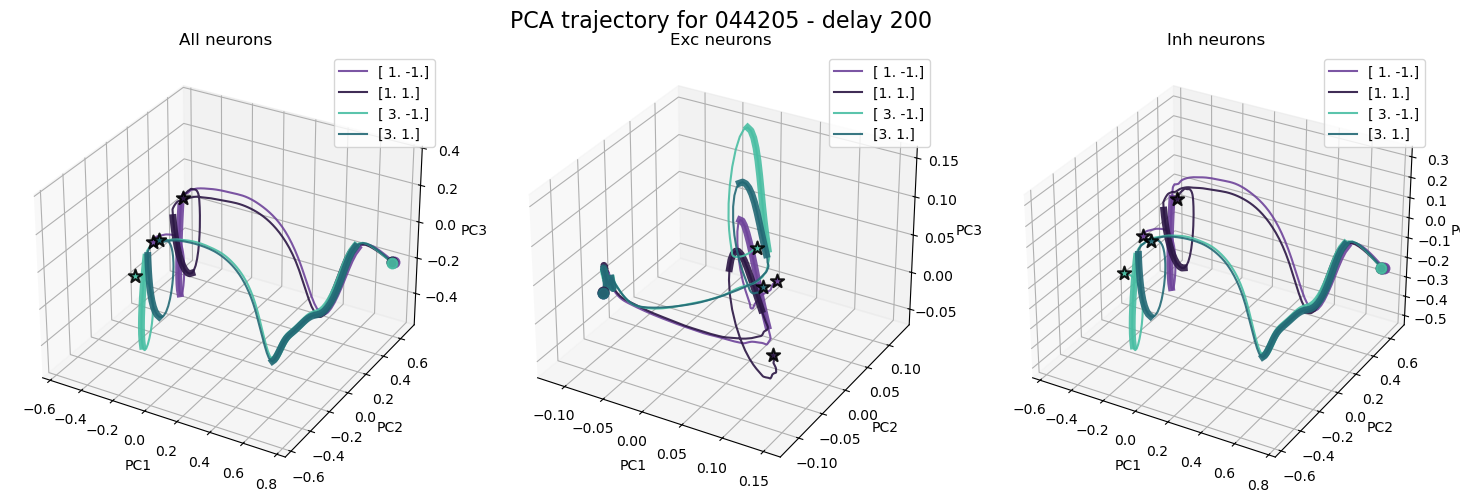

In [75]:
import population_utils as pu
importlib.reload(pu)
importlib.reload(ld)

# make 3d plot with 3 subplots
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(131, projection='3d')
ax2 = fig.add_subplot(132, projection='3d')
ax3 = fig.add_subplot(133, projection='3d')
_, pca_all = pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=200,
                   rates_data=rates_data, trial_labels=trial_labels,
                   neuron_ids=None, cut_off=25, 
                   ds=2, sigma=5, ax=ax1, title='All neurons',
                   all_models_dir=all_models_dir)
_, pca_exc = pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=200,
                   neuron_ids=exc_ind, rates_data=rates_data, trial_labels=trial_labels, cut_off=25, 
                   ds=2, sigma=5, ax=ax2, title='Exc neurons',
                   all_models_dir=all_models_dir)
_, pca_inh = pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=200,
                   neuron_ids=inh_ind, rates_data=rates_data, trial_labels=trial_labels, cut_off=25,
                   ds=2, sigma=5, ax=ax3, title='Inh neurons',
                   all_models_dir=all_models_dir)
plt.suptitle(f'PCA trajectory for {model_name[-6:]} - {condn_phrase} {200}', fontsize=16)
plt.tight_layout()
plt.show()

PCA explained variance: [0.53429865 0.16699688 0.10972333], total: 0.8110188635717276
PCA explained variance: [0.756605  0.1655183 0.0426383], total: 0.9647615941261241


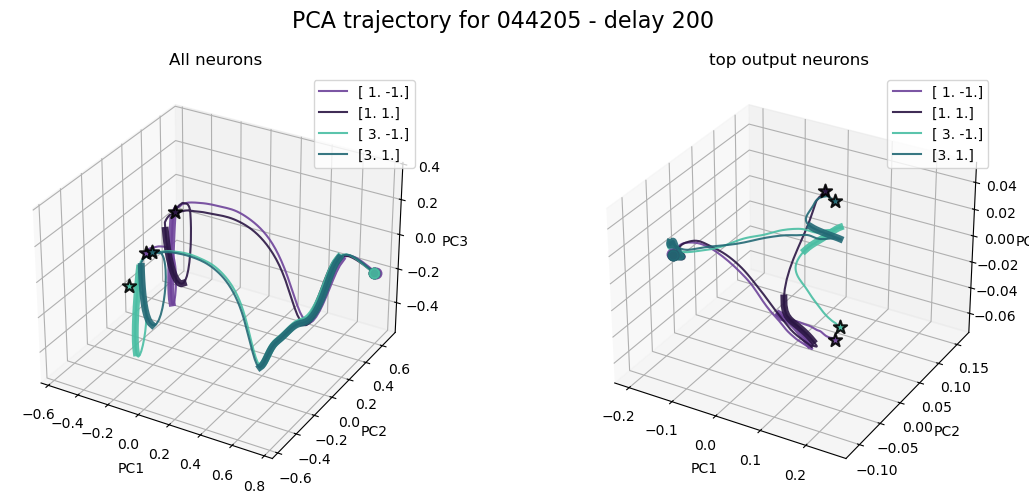

In [77]:
import population_utils as pu
importlib.reload(pu)
importlib.reload(ld)

# make 3d plot with 2 subplots
fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')
_, pca_all = pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=200,
                   rates_data=rates_data, trial_labels=trial_labels,
                   neuron_ids=None, cut_off=25, 
                   ds=2, sigma=5, ax=ax1, title='All neurons',
                   all_models_dir=all_models_dir)
_, pca_top = pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=200,
                   neuron_ids=top_idxs, rates_data=rates_data, trial_labels=trial_labels, cut_off=25, 
                   ds=2, sigma=5, ax=ax2, title='top output neurons',
                   all_models_dir=all_models_dir)
plt.suptitle(f'PCA trajectory for {model_name[-6:]} - {condn_phrase} {200}', fontsize=16)
plt.tight_layout()
plt.show()

In [78]:
trial_perfs = np.concatenate((trial_perfs_match, trial_perfs_stim), axis=0)

rates_corr = rates_data[trial_perfs == 1,:,:]
rates_incorr = rates_data[trial_perfs == 0,:,:]

trials_labels_corr = trial_labels[trial_perfs == 1]
trials_labels_incorr = trial_labels[trial_perfs == 0]

Accuracy for 044205: 0.7052238805970149
PCA explained variance: [0.756605  0.1655183 0.0426383], total: 0.9647615941261241
PCA explained variance: [0.756605  0.1655183 0.0426383], total: 0.9647615941261241


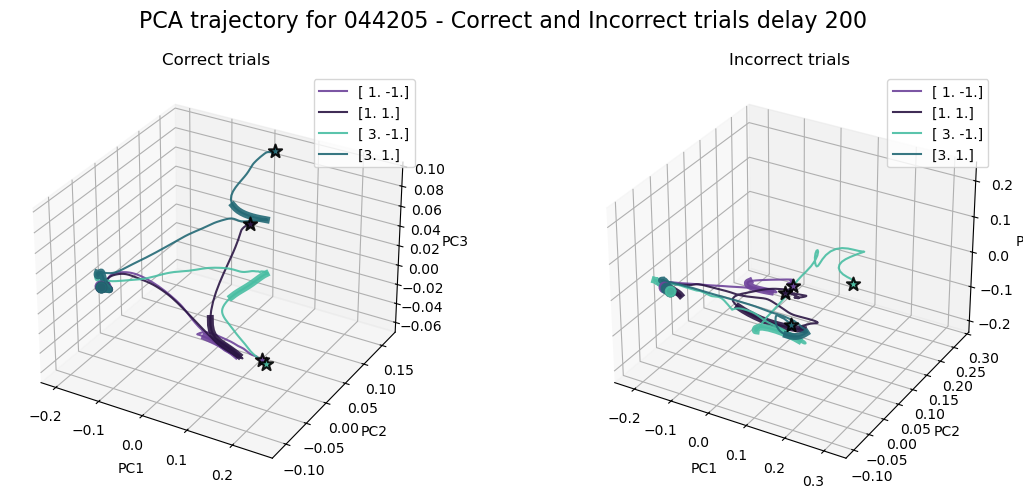

In [80]:
# plot correct and incorrect next to each other

print(f'Accuracy for {model_name[-6:]}: {trial_perfs.mean()}')

fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=200, pca_obj = pca_top,
                   neuron_ids=top_idxs, rates_data=rates_corr, trial_labels=trials_labels_corr, 
                   ds=2, sigma=5,
                   cut_off=25, ax=ax1, title='Correct trials',
                   all_models_dir=all_models_dir)
pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=200, pca_obj = pca_top,
                   neuron_ids=top_idxs, rates_data=rates_incorr, trial_labels=trials_labels_incorr, 
                   ds=2, sigma=5,
                   cut_off=25, ax=ax2, title='Incorrect trials',
                   all_models_dir=all_models_dir)
plt.suptitle(f'PCA trajectory for {model_name[-6:]} - Correct and Incorrect trials {condn_phrase} {200}', fontsize=16)
plt.tight_layout()
plt.show()##

In [82]:
all_models_dir

'/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5'

In [83]:
importlib.reload(ld)
connectivity_df = ld.get_connectivity_df(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)
connectivity_df.head()

,presyn_id,postsyn_id,weight,presyn_type,postsyn_type
0,11,0,-0.079704,inh,exc
1,11,5,-0.080036,inh,exc
2,11,18,-0.070888,inh,exc
3,11,38,-0.041342,inh,exc
4,11,43,-0.042320,inh,exc


In [88]:
top_idxs

array([879, 399, 123, 112, 877,  84,  22, 266, 765, 194, 330, 205])

In [ ]:
top_connectivity_presyn = connectivity_df.loc[connectivity_df["presyn_id"].isin(top_idxs)]
top_connectivity_presyn

,presyn_id,postsyn_id,weight,presyn_type,postsyn_type
314,22,1,-0.017616,inh,exc
315,22,7,-0.065255,inh,exc
316,22,12,-0.030989,inh,inh
317,22,13,-0.057996,inh,exc
318,22,16,-0.067774,inh,exc
...,...,...,...,...,...
29081,879,979,-0.047940,inh,exc
29082,879,984,-0.066629,inh,exc
29083,879,990,-0.038206,inh,inh
29084,879,991,-0.048992,inh,exc


In [89]:
top_connectivity_postsyn = connectivity_df.loc[connectivity_df["postsyn_id"].isin(top_idxs)]
top_connectivity_postsyn

,presyn_id,postsyn_id,weight,presyn_type,postsyn_type
208,12,399,-0.021138,inh,exc
294,12,877,-0.057269,inh,exc
320,22,22,-0.016634,inh,inh
481,34,84,-0.028447,inh,exc
492,34,123,-0.050887,inh,exc
...,...,...,...,...,...
31939,995,205,-0.084373,inh,exc
32032,995,765,-0.089223,inh,exc
32058,995,877,-0.042633,inh,exc
32094,996,112,-0.040773,inh,inh
